# Nested-protocol elasticity benchmark

This notebook reads the nested protocol tables (OLS, Ridge, MLP, ICDN) with the same comparison rules as the paper. Panels: Walmart M5, 1C Predict Future Sales, and Dominick beer (a directory is used only if it exists).

- predictive comparisons use **matched cells**;
- cross-price comparisons use **matched edges**;
- bootstrap uncertainty is **series-level**, not a CI for a global parameter.

Current constants (`N_FOLDS=2`, a small Optuna budget, `N_BOOT=2`) are a smoke run. The numbers check the pipeline; they are not publication estimates until the experiment is repeated at full budget.

**ICDN vs MLP** is the main contrast. Two paired analyses sit on top of the per-model tables:

1. **Predictive inference.** Concatenate outer-validation predictions, form \(d_{ist}=|y-\hat y^{\mathrm{ICDN}}|-|y-\hat y^{\mathrm{MLP}}|\), and week-block bootstrap \(\Delta\mathrm{MAE}\) without retraining. The non-inferiority margin \(\delta=\) `PRED_NI_MARGIN` is a pre-specified design constant.
2. **Bootstrap stability.** For each series, use the **intersection** of bootstrap IDs in `bootstrap_replicates.csv`. ICDN cross-price `edge_selection_frequency` is reported separately from the SD of the elasticity when the edge is present.


In [1]:
from pathlib import Path
import json
import sys
import warnings

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd() if Path.cwd().name != "notebooks" else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.benchmarks.constants import (
    N_BOOT_ICDN,
    N_BOOT_LINEAR,
    N_BOOT_MLP,
    N_BOOT_PRED_INFER,
    N_FOLDS,
    N_TRIALS_ICDN,
    N_TRIALS_MLP,
    PRED_NI_MARGIN,
    SEED,
)
from src.benchmarks.paired import (
    ELAST_CLIP,
    best_complete_trial,
    clips_for,
    elasticity_clip_diagnostics,
    elasticity_distribution,
    share_obs_both,
)
from src.benchmarks.predict import COMPARE_MODELS, LINEAR_MODELS, NEURAL_MODELS
from src.benchmarks.reporting import concat_model_csv, rebuild_all

rebuild_all(ROOT)

PANELS = {
    "walmart": ROOT / "data" / "M5-walmart" / "panel",
    "one_c": ROOT / "data" / "predict-future-sales-1c" / "panel",
    "dominick": ROOT / "data" / "Dominick" / "panel",
}
PANELS = {k: v for k, v in PANELS.items() if v.exists()}
FIG = ROOT / "notebooks" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = list(COMPARE_MODELS)
MODEL_LABEL = {"ols": "OLS", "ridge": "Ridge", "mlp": "MLP", "icdn": "ICDN"}
DATASET_LABEL = {
    "walmart": "Walmart M5 (FOODS_3)",
    "one_c": "1C (Predict Future Sales)",
    "dominick": "Dominick (beer)",
}
KIND_LABEL = {"own": "own-price", "cross": "cross-price", "own_eq": "own-price (equation)"}
COLOR = {"ols": "#E69F00", "ridge": "#56B4E9", "mlp": "#009E73", "icdn": "#CC79A7"}
CONCLUSION_LABEL = {
    "icdn_superior": "ICDN superior (95% CI for ΔMAE lies below 0)",
    "mlp_superior": "MLP superior (95% CI for ΔMAE lies above 0)",
    "icdn_noninferior": "ICDN non-inferior (CI excludes ΔMAE ≥ δ)",
    "indistinguishable": "Indistinguishable at this sample",
    "undefined": "Undefined",
}

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "font.size": 10.5,
    "axes.titlesize": 11.5,
    "axes.labelsize": 10.5,
    "legend.frameon": False,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

print(
    f"N_FOLDS={N_FOLDS}  N_TRIALS_MLP={N_TRIALS_MLP}  N_TRIALS_ICDN={N_TRIALS_ICDN}  "
    f"N_BOOT linear/MLP/ICDN={N_BOOT_LINEAR}/{N_BOOT_MLP}/{N_BOOT_ICDN}  "
    f"N_BOOT_PRED_INFER={N_BOOT_PRED_INFER}  PRED_NI_MARGIN={PRED_NI_MARGIN}  SEED={SEED}"
)


/home/thebigmonster/Github/nn-elasticity-additional-work/venv-icdn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== rebuild /home/thebigmonster/Github/nn-elasticity-additional-work/data/M5-walmart/panel

=== rebuild /home/thebigmonster/Github/nn-elasticity-additional-work/data/predict-future-sales-1c/panel

=== rebuild /home/thebigmonster/Github/nn-elasticity-additional-work/data/Dominick/panel
N_FOLDS=3  N_TRIALS_MLP=100  N_TRIALS_ICDN=100  N_BOOT linear/MLP/ICDN=100/100/100  N_BOOT_PRED_INFER=999  PRED_NI_MARGIN=0.05  SEED=42


In [2]:
def read_csv(path: Path) -> pd.DataFrame:
    if path is None or not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


def load_all(name: str, panel: Path) -> pd.DataFrame:
    return concat_model_csv(panel, name)


def show_table(df: pd.DataFrame, caption: str, na="—", floatfmt=4):
    out = df.copy()
    for col in out.select_dtypes(include=["float", "float64", "float32"]).columns:
        out[col] = out[col].map(lambda x: na if pd.isna(x) else f"{x:.{floatfmt}f}")
    display(Markdown(f"**{caption}**"))
    display(out)
    return df


def savefig(fig, stem: str):
    fig.savefig(FIG / f"{stem}.pdf")
    fig.savefig(FIG / f"{stem}.png")
    print("  figure", FIG / f"{stem}.pdf")


def present_folds(kfold: pd.DataFrame) -> set[str]:
    if kfold.empty or "fold" not in kfold.columns:
        return set()
    return set(kfold["fold"].astype(str))


def inventory(panel: Path) -> pd.DataFrame:
    rows = []
    expected = [
        "kfold.csv", "kfold_series.csv", "kfold_series_stats.csv",
        "holdout_pred_cells.csv", "holdout_elasticities.csv",
        "bootstrap.csv", "bootstrap_replicates.csv", "bootstrap_series_ci.csv",
        "bootstrap_matched.csv", "bootstrap_matched_global.csv",
        "holdout_in_boot_ci.csv", "boot_fold_ratio.csv", "fold_in_boot_ci.csv",
        "bootstrap_manifest.json",
    ]
    shared = [
        "matched_prediction_metrics.csv", "matched_elasticity_series.csv",
        "pred_matched_kfold.csv", "pred_matched_holdout.csv",
        "edge_matched_kfold.csv", "edge_matched_kfold_sd.csv", "edge_matched_kfold_coverage.csv",
        "paired_bootstrap_stability.csv", "paired_bootstrap_summary.csv",
        "paired_predictive_inference.csv", "paired_predictive_series.csv",
        "split_plan.json", "split_plan.csv", "bootstrap_plan.json",
        "run_manifest.csv", "bootstrap_manifest.csv", "run_failures.csv",
        "spline_support_diagnostics.csv",
    ]
    for model in MODEL_ORDER:
        mdir = panel / model
        for name in expected:
            rows.append({"model": model, "file": name, "present": (mdir / name).exists()})
        for path in sorted(mdir.glob("fold*_pred_cells.csv")):
            rows.append({"model": model, "file": path.name, "present": True})
        for path in sorted(mdir.glob("fold*_elasticities_long.csv")):
            rows.append({"model": model, "file": path.name, "present": True})
        for path in sorted(mdir.glob("fold*_pred_ij.csv")):
            rows.append({"model": model, "file": path.name, "present": True})
        for path in sorted(mdir.glob("*/optuna_trials.csv")):
            rows.append({"model": model, "file": str(path.relative_to(mdir)), "present": True})
    for name in shared:
        rows.append({"model": "(panel)", "file": name, "present": (panel / name).exists()})
    return pd.DataFrame(rows)


## 0. Inventory

Before interpreting a statistic, check which files exist. Missing neural holdout or bootstrap files are gaps, not zeros. `bootstrap_plan.json` is the shared draw for the dataset; `bootstrap_manifest.csv` flattens per-model audit JSON.


In [3]:
for key, panel in PANELS.items():
    inv = inventory(panel)
    missing = inv[~inv["present"]]
    print(f"\n=== {DATASET_LABEL[key]} ===")
    print("present", int(inv["present"].sum()), "/", len(inv), "rows")
    if len(missing):
        show_table(missing[["model", "file"]], "Missing files (not interpreted as zeros)")
    else:
        print("no expected files missing")
    kfold = load_all("kfold.csv", panel)
    if len(kfold):
        print("folds in kfold.csv:", sorted(kfold.groupby("model")["fold"].apply(lambda s: sorted(s.unique())).to_dict().items()))



=== Walmart M5 (FOODS_3) ===
present 106 / 106 rows
no expected files missing
folds in kfold.csv: [('icdn', [np.int64(1), np.int64(2), np.int64(3)]), ('mlp', [np.int64(1), np.int64(2), np.int64(3)]), ('ols', [np.int64(1), np.int64(2), np.int64(3)]), ('ridge', [np.int64(1), np.int64(2), np.int64(3)])]

=== 1C (Predict Future Sales) ===
present 106 / 106 rows
no expected files missing
folds in kfold.csv: [('icdn', [np.int64(1), np.int64(2), np.int64(3)]), ('mlp', [np.int64(1), np.int64(2), np.int64(3)]), ('ols', [np.int64(1), np.int64(2), np.int64(3)]), ('ridge', [np.int64(1), np.int64(2), np.int64(3)])]

=== Dominick (beer) ===
present 106 / 106 rows
no expected files missing
folds in kfold.csv: [('icdn', [np.int64(1), np.int64(2), np.int64(3)]), ('mlp', [np.int64(1), np.int64(2), np.int64(3)]), ('ols', [np.int64(1), np.int64(2), np.int64(3)]), ('ridge', [np.int64(1), np.int64(2), np.int64(3)])]


## 1. Outer-fold prediction (native)

`kfold.csv` summarises each dataset–model–fold on the cells that model can predict. `cross_mean` is the average over that **native** pair set and is not comparable across models: ICDN estimates a neighbourhood, MLP the full Jacobian, OLS/Ridge the equations that pass VIF/d.f. gates.

The MAE figure shows time variation across outer folds. Coverage and compute stay in the table so the chart is not a mix of seconds, GPU-hours, and trial counts.


In [4]:
def kfold_prediction_table(kfold: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "dataset", "model", "fold", "mae_val", "rmse_val", "r2_val",
        "n_cells", "n_validation_cells", "prediction_coverage",
        "n_own", "n_cross", "own_mean", "cross_mean",
        "n_parameters", "completed_trials", "pruned_trials", "failed_trials",
        "tuning_seconds", "fit_seconds", "gpu_hours",
    ]
    keep = [c for c in cols if c in kfold.columns]
    out = kfold[keep].copy()
    out["model"] = pd.Categorical(out["model"], MODEL_ORDER, ordered=True)
    return out.sort_values(["dataset", "fold", "model"])


parts = []
for k, p in PANELS.items():
    df = load_all("kfold.csv", p)
    if len(df):
        parts.append(df)
all_kfold = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
show_table(kfold_prediction_table(all_kfold), "Table 1. Native metrics by outer fold")


**Table 1. Native metrics by outer fold**

,dataset,model,fold,mae_val,rmse_val,r2_val,n_cells,n_validation_cells,prediction_coverage,n_own,n_cross,own_mean,cross_mean,n_parameters,completed_trials,pruned_trials,failed_trials,tuning_seconds,fit_seconds,gpu_hours
24,dominick,ols,1,0.4200,0.5609,0.8103,14188,14188,1.0000,400,7113,-4.6362,0.2727,41524,0,0,0,0.0000,236.2295,0.0000
27,dominick,ridge,1,0.4205,0.5627,0.8091,14188,14188,1.0000,400,7113,-3.6763,0.0131,41524,0,0,0,0.0000,263.2531,0.0000
30,dominick,mlp,1,0.4299,0.5685,0.8051,14188,14188,1.0000,400,7600,-0.9525,-0.0430,182308,56,44,0,208.3133,1.3597,0.0582
33,dominick,icdn,1,0.4804,0.6226,0.7663,14188,14188,1.0000,400,1200,-2.4105,0.5457,21229,31,69,0,916.1468,11.7403,0.2577
25,dominick,ols,2,0.4605,0.6174,0.7807,14246,14246,1.0000,400,7099,-4.7676,0.1633,41558,0,0,0,0.0000,235.6811,0.0000
28,dominick,ridge,2,0.4598,0.6151,0.7824,14246,14246,1.0000,400,7099,-3.9323,0.0035,41558,0,0,0,0.0000,265.1372,0.0000
31,dominick,mlp,2,0.4393,0.5630,0.8176,14246,14246,1.0000,400,7600,-0.8232,-0.0351,182308,44,56,0,223.8836,1.7241,0.0627
34,dominick,icdn,2,0.4128,0.5461,0.8285,14246,14246,1.0000,400,800,-2.7293,0.5193,23617,22,78,0,1086.1326,16.2571,0.3062
26,dominick,ols,3,0.4904,0.6368,0.7604,14851,14851,1.0000,400,7151,-4.6960,0.0654,41847,0,0,0,0.0000,240.9759,0.0000
29,dominick,ridge,3,0.4803,0.6282,0.7669,14851,14851,1.0000,400,7151,-3.9905,0.0001,41847,0,0,0,0.0000,272.9957,0.0000


,dataset,model,fold,mae_val,rmse_val,r2_val,n_cells,n_validation_cells,prediction_coverage,n_own,n_cross,own_mean,cross_mean,n_parameters,completed_trials,pruned_trials,failed_trials,tuning_seconds,fit_seconds,gpu_hours
24,dominick,ols,1,0.420040,0.560876,0.810335,14188,14188,1.000000,400,7113,-4.636185,0.272739,41524,0,0,0,0.000000,236.229490,0.000000
27,dominick,ridge,1,0.420459,0.562662,0.809125,14188,14188,1.000000,400,7113,-3.676340,0.013114,41524,0,0,0,0.000000,263.253070,0.000000
30,dominick,mlp,1,0.429882,0.568494,0.805148,14188,14188,1.000000,400,7600,-0.952537,-0.042994,182308,56,44,0,208.313310,1.359734,0.058243
33,dominick,icdn,1,0.480367,0.622643,0.766261,14188,14188,1.000000,400,1200,-2.410485,0.545691,21229,31,69,0,916.146806,11.740307,0.257746
25,dominick,ols,2,0.460508,0.617410,0.780732,14246,14246,1.000000,400,7099,-4.767625,0.163331,41558,0,0,0,0.000000,235.681098,0.000000
28,dominick,ridge,2,0.459771,0.615114,0.782360,14246,14246,1.000000,400,7099,-3.932281,0.003453,41558,0,0,0,0.000000,265.137203,0.000000
31,dominick,mlp,2,0.439321,0.563042,0.817649,14246,14246,1.000000,400,7600,-0.823185,-0.035085,182308,44,56,0,223.883595,1.724105,0.062669
34,dominick,icdn,2,0.412810,0.546081,0.828470,14246,14246,1.000000,400,800,-2.729321,0.519290,23617,22,78,0,1086.132553,16.257059,0.306219
26,dominick,ols,3,0.490357,0.636826,0.760413,14851,14851,1.000000,400,7151,-4.696004,0.065421,41847,0,0,0,0.000000,240.975881,0.000000
29,dominick,ridge,3,0.480335,0.628188,0.766869,14851,14851,1.000000,400,7151,-3.990504,0.000148,41847,0,0,0,0.000000,272.995707,0.000000


  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_kfold_mae.pdf


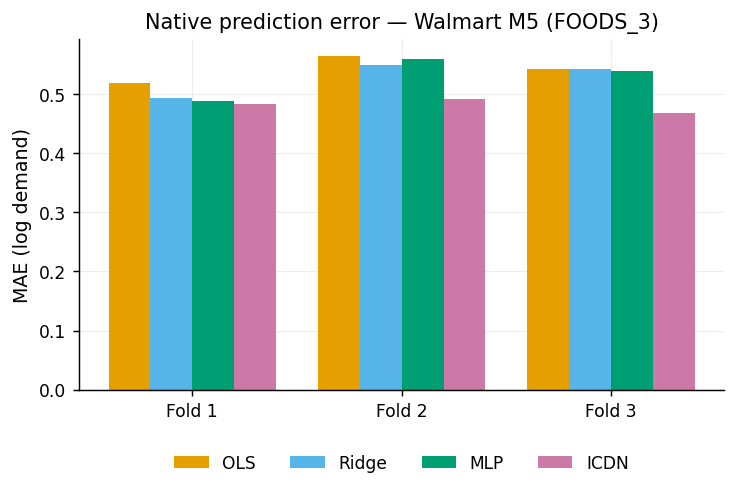

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_kfold_coverage.pdf


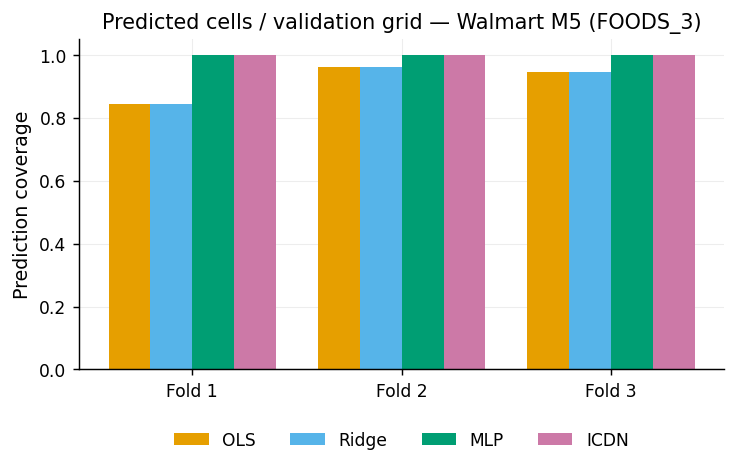

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/one_c_kfold_mae.pdf


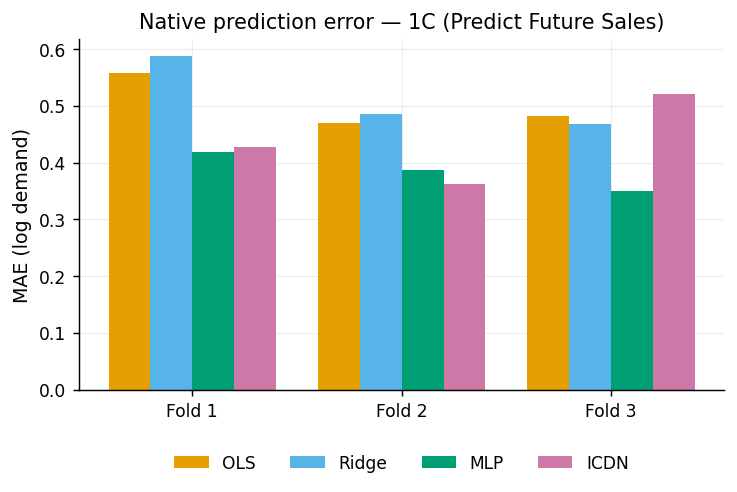

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/one_c_kfold_coverage.pdf


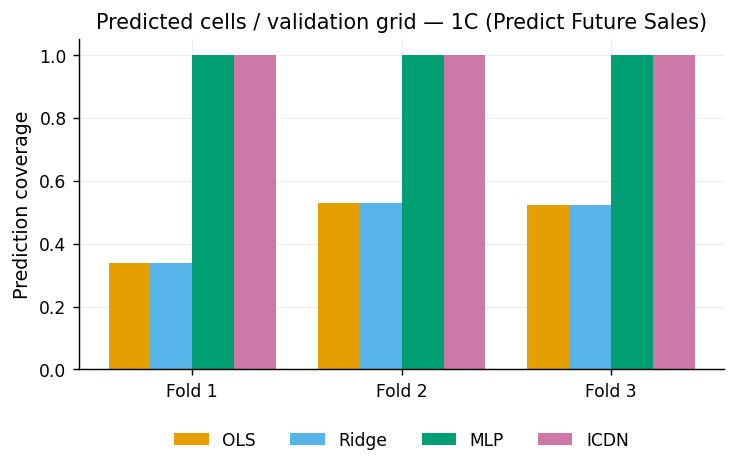

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_kfold_mae.pdf


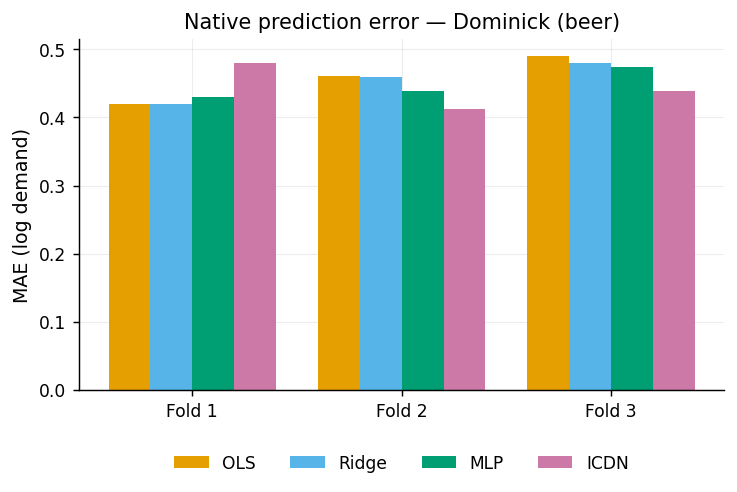

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_kfold_coverage.pdf


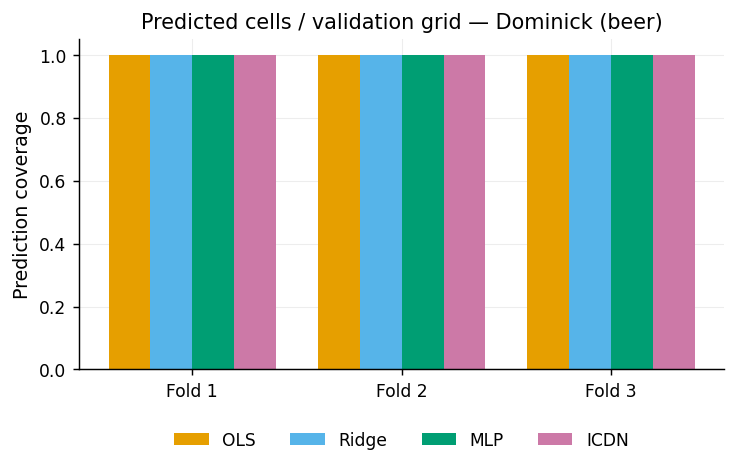

**Table 2. Prediction, Optuna budget, and compute (sums over folds)**

,dataset,model,n_folds,mae_mean,mae_sd,r2_mean,coverage_mean,n_parameters,completed_trials,pruned_trials,failed_trials,fit_seconds,gpu_hours
0,dominick,icdn,3,0.4439,0.0341,0.8021,1.0000,22003.6667,93,207,0,46.4975,1.0635
1,dominick,mlp,3,0.4479,0.0235,0.8024,1.0000,182308.0000,155,145,0,4.6479,0.2003
2,dominick,ols,3,0.4570,0.0353,0.7838,1.0000,41643.0000,0,0,0,712.8865,0.0000
3,dominick,ridge,3,0.4535,0.0304,0.7861,1.0000,41643.0000,0,0,0,801.3860,0.0000
4,one_c,icdn,3,0.4368,0.0797,-0.4663,1.0000,62486.3333,83,217,0,22.0154,0.5200
5,one_c,mlp,3,0.3846,0.0341,0.0353,1.0000,107418.0000,131,169,0,0.8279,0.0504
6,one_c,ols,3,0.5035,0.0480,-0.3592,0.4630,1668.0000,0,0,0,9.5450,0.0000
7,one_c,ridge,3,0.5137,0.0646,-0.2581,0.4630,1668.0000,0,0,0,13.2347,0.0000
8,walmart,icdn,3,0.4807,0.0120,0.6915,1.0000,21025.0000,93,207,0,29.1918,0.7026
9,walmart,mlp,3,0.5283,0.0367,0.6404,1.0000,166788.0000,120,180,0,2.8078,0.1162


,dataset,model,n_folds,mae_mean,mae_sd,r2_mean,coverage_mean,n_parameters,completed_trials,pruned_trials,failed_trials,fit_seconds,gpu_hours
0,dominick,icdn,3,0.443865,0.034106,0.802144,1.000000,22003.666667,93,207,0,46.497535,1.063509
1,dominick,mlp,3,0.447865,0.023453,0.802397,1.000000,182308.000000,155,145,0,4.647888,0.200303
2,dominick,ols,3,0.456968,0.035292,0.783827,1.000000,41643.000000,0,0,0,712.886469,0.000000
3,dominick,ridge,3,0.453522,0.030423,0.786118,1.000000,41643.000000,0,0,0,801.385980,0.000000
4,one_c,icdn,3,0.436800,0.079731,-0.466288,1.000000,62486.333333,83,217,0,22.015427,0.520007
5,one_c,mlp,3,0.384596,0.034110,0.035312,1.000000,107418.000000,131,169,0,0.827898,0.050367
6,one_c,ols,3,0.503470,0.048001,-0.359247,0.462986,1668.000000,0,0,0,9.544968,0.000000
7,one_c,ridge,3,0.513707,0.064639,-0.258060,0.462986,1668.000000,0,0,0,13.234665,0.000000
8,walmart,icdn,3,0.480669,0.011985,0.691542,1.000000,21025.000000,93,207,0,29.191823,0.702564
9,walmart,mlp,3,0.528325,0.036703,0.640417,1.000000,166788.000000,120,180,0,2.807791,0.116197


In [5]:
def plot_mae_by_fold(kfold: pd.DataFrame, dataset: str, stem: str):
    df = kfold[kfold["dataset"] == dataset].copy()
    if df.empty:
        return
    folds = sorted(df["fold"].unique())
    fig, ax = plt.subplots(figsize=(6.4, 3.5))
    width = 0.8 / max(len(MODEL_ORDER), 1)
    x = np.arange(len(folds))
    for i, model in enumerate(MODEL_ORDER):
        part = df[df["model"] == model].set_index("fold")
        vals = [part.loc[f, "mae_val"] if f in part.index else np.nan for f in folds]
        ax.bar(x + (i - 1.5) * width, vals, width=width, color=COLOR[model], label=MODEL_LABEL[model])
    ax.set_xticks(x)
    ax.set_xticklabels([f"Fold {f}" for f in folds])
    ax.set_ylabel("MAE (log demand)")
    ax.set_title(f"Native prediction error — {DATASET_LABEL[dataset]}")
    ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.14))
    savefig(fig, stem)
    plt.show()
    plt.close(fig)


def plot_coverage(kfold: pd.DataFrame, dataset: str, stem: str):
    df = kfold[kfold["dataset"] == dataset].copy()
    if df.empty or "prediction_coverage" not in df.columns:
        return
    folds = sorted(df["fold"].unique())
    fig, ax = plt.subplots(figsize=(6.4, 3.3))
    width = 0.8 / max(len(MODEL_ORDER), 1)
    x = np.arange(len(folds))
    for i, model in enumerate(MODEL_ORDER):
        part = df[df["model"] == model].set_index("fold")
        vals = [part.loc[f, "prediction_coverage"] if f in part.index else np.nan for f in folds]
        ax.bar(x + (i - 1.5) * width, vals, width=width, color=COLOR[model], label=MODEL_LABEL[model])
    ax.set_xticks(x)
    ax.set_xticklabels([f"Fold {f}" for f in folds])
    ax.set_ylabel("Prediction coverage")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Predicted cells / validation grid — {DATASET_LABEL[dataset]}")
    ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.14))
    savefig(fig, stem)
    plt.show()
    plt.close(fig)


for key in PANELS:
    sub = all_kfold[all_kfold["dataset"] == key]
    if sub.empty:
        continue
    plot_mae_by_fold(all_kfold, key, f"{key}_kfold_mae")
    plot_coverage(all_kfold, key, f"{key}_kfold_coverage")

cost = all_kfold.groupby(["dataset", "model"], as_index=False).agg(
    n_folds=("fold", "nunique"),
    mae_mean=("mae_val", "mean"),
    mae_sd=("mae_val", "std"),
    r2_mean=("r2_val", "mean"),
    coverage_mean=("prediction_coverage", "mean"),
    n_parameters=("n_parameters", "mean"),
    completed_trials=("completed_trials", "sum"),
    pruned_trials=("pruned_trials", "sum"),
    failed_trials=("failed_trials", "sum"),
    fit_seconds=("fit_seconds", "sum"),
    gpu_hours=("gpu_hours", "sum"),
)
show_table(cost, "Table 2. Prediction, Optuna budget, and compute (sums over folds)")


## 2. Matched-cell prediction

`fold{k}_pred_cells.csv` is the validation grid with `y_true` and `y_pred` (NaN if the model does not predict that cell). Native MAE uses finite cells of each model; matched MAE uses the intersection.

`matched_prediction_metrics.csv` compares model pairs on the same observations. \(\Delta\mathrm{MAE}=\mathrm{MAE}_a-\mathrm{MAE}_b\); negative favours \(a\). Fold-level \(\Delta\mathrm{MAE}\) is a point contrast only — Section 3 puts a CI on the pooled ICDN–MLP difference.


In [6]:
def error_by_group(grid: pd.DataFrame, group: str) -> pd.DataFrame:
    g = grid.dropna(subset=["y_true", "y_pred"]).copy()
    g["abs_err"] = (g["y_true"] - g["y_pred"]).abs()
    return g.groupby(group, as_index=False).agg(mae=("abs_err", "mean"), n=("abs_err", "size"))


def pred_cells(panel: Path, model: str, fold) -> pd.DataFrame:
    name = "holdout_pred_cells.csv" if str(fold) == "holdout" else f"fold{fold}_pred_cells.csv"
    return read_csv(panel / model / name)


matched_pred = pd.concat(
    [read_csv(p / "matched_prediction_metrics.csv") for p in PANELS.values()],
    ignore_index=True,
)
if len(matched_pred):
    icdn_mlp = matched_pred[(matched_pred["model_a"] == "icdn") & (matched_pred["model_b"] == "mlp")]
    show_table(
        icdn_mlp[["dataset", "fold", "n_common_cells", "mae_a", "mae_b", "rmse_a", "rmse_b", "r2_a", "r2_b", "delta_mae", "delta_rmse", "delta_r2"]],
        "Table 3. ICDN vs MLP on matched cells (a = ICDN, b = MLP)",
    )
    show_table(
        matched_pred[matched_pred["fold"].astype(str) != "holdout"][
            ["dataset", "fold", "model_a", "model_b", "n_common_cells", "mae_a", "mae_b", "delta_mae", "r2_a", "r2_b"]
        ].sort_values(["dataset", "fold", "model_a", "model_b"]),
        "Table 4. All matched-cell pairs (outer folds)",
    )


**Table 3. ICDN vs MLP on matched cells (a = ICDN, b = MLP)**

,dataset,fold,n_common_cells,mae_a,mae_b,rmse_a,rmse_b,r2_a,r2_b,delta_mae,delta_rmse,delta_r2
0,walmart,1,8217,0.4831,0.4876,0.6766,0.6674,0.6634,0.6724,-0.0045,0.0091,-0.0090
6,walmart,2,7268,0.4913,0.5590,0.6926,0.7679,0.6904,0.6195,-0.0677,-0.0753,0.0709
12,walmart,3,7297,0.4677,0.5384,0.6417,0.7394,0.7208,0.6294,-0.0707,-0.0977,0.0914
18,walmart,holdout,8453,0.4456,0.5736,0.6393,0.7584,0.7297,0.6196,-0.1280,-0.1191,0.1101
24,one_c,1,1807,0.4281,0.4177,0.5417,0.5325,0.0445,0.0769,0.0104,0.0093,-0.0324
30,one_c,2,1329,0.3618,0.3864,0.5080,0.5017,-0.0370,-0.0115,-0.0247,0.0063,-0.0255
36,one_c,3,744,0.5205,0.3496,0.6535,0.4126,-1.4064,0.0405,0.1709,0.2408,-1.4469
42,one_c,holdout,903,0.9928,0.3226,1.2579,0.3978,-8.2674,0.0734,0.6702,0.8601,-8.3408
48,dominick,1,14188,0.4804,0.4299,0.6226,0.5685,0.7663,0.8051,0.0505,0.0541,-0.0389
54,dominick,2,14246,0.4128,0.4393,0.5461,0.5630,0.8285,0.8176,-0.0265,-0.0170,0.0108


**Table 4. All matched-cell pairs (outer folds)**

,dataset,fold,model_a,model_b,n_common_cells,mae_a,mae_b,delta_mae,r2_a,r2_b
48,dominick,1,icdn,mlp,14188,0.4804,0.4299,0.0505,0.7663,0.8051
50,dominick,1,icdn,ols,14188,0.4804,0.4200,0.0603,0.7663,0.8103
49,dominick,1,icdn,ridge,14188,0.4804,0.4205,0.0599,0.7663,0.8091
52,dominick,1,mlp,ols,14188,0.4299,0.4200,0.0098,0.8051,0.8103
51,dominick,1,mlp,ridge,14188,0.4299,0.4205,0.0094,0.8051,0.8091
53,dominick,1,ridge,ols,14188,0.4205,0.4200,0.0004,0.8091,0.8103
54,dominick,2,icdn,mlp,14246,0.4128,0.4393,-0.0265,0.8285,0.8176
56,dominick,2,icdn,ols,14246,0.4128,0.4605,-0.0477,0.8285,0.7807
55,dominick,2,icdn,ridge,14246,0.4128,0.4598,-0.0470,0.8285,0.7824
58,dominick,2,mlp,ols,14246,0.4393,0.4605,-0.0212,0.8176,0.7807


  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_fold1_mae_store.pdf


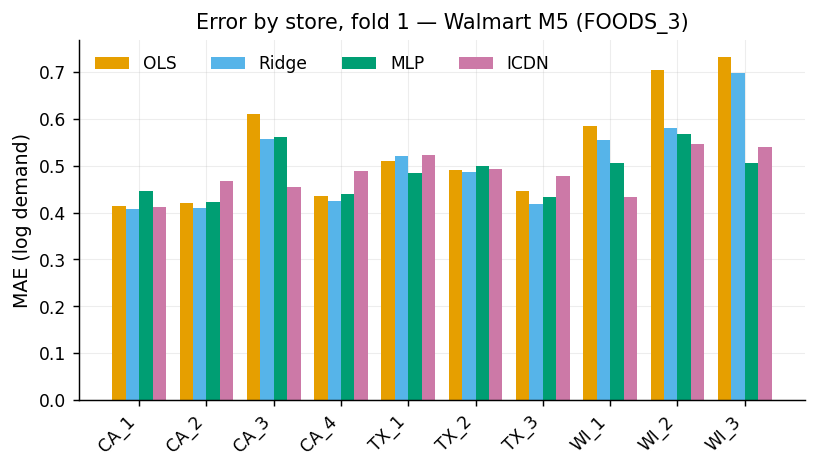

**Ten products with the largest MAE range across models (Walmart M5 (FOODS_3), fold 1)**

,product_code,ols,n_ols,ridge,n_ridge,mlp,n_mlp,icdn,n_icdn,mae_range
9,FOODS_3_448,0.3908,321,0.3908,321,0.4678,459,0.6220,459,0.2312
13,FOODS_3_541,0.6387,424,0.5889,424,0.4729,424,0.4507,424,0.1880
12,FOODS_3_534,0.4506,435,0.4563,435,0.6160,435,0.6195,435,0.1689
16,FOODS_3_635,0.6338,425,0.6266,425,0.4880,425,0.4784,425,0.1554
15,FOODS_3_615,0.6974,352,0.6671,352,0.5430,390,0.6657,390,0.1544
0,FOODS_3_041,0.5543,91,0.5719,91,0.6138,457,0.4757,457,0.1382
2,FOODS_3_115,0.5898,313,0.5357,313,0.4578,390,0.5050,390,0.1320
11,FOODS_3_524,0.5345,375,0.5188,375,0.5642,421,0.4347,421,0.1295
8,FOODS_3_404,0.5244,371,0.4694,371,0.4500,412,0.4036,412,0.1208
3,FOODS_3_124,0.5210,385,0.4865,385,0.4759,385,0.4073,385,0.1137


  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/one_c_fold1_mae_store.pdf


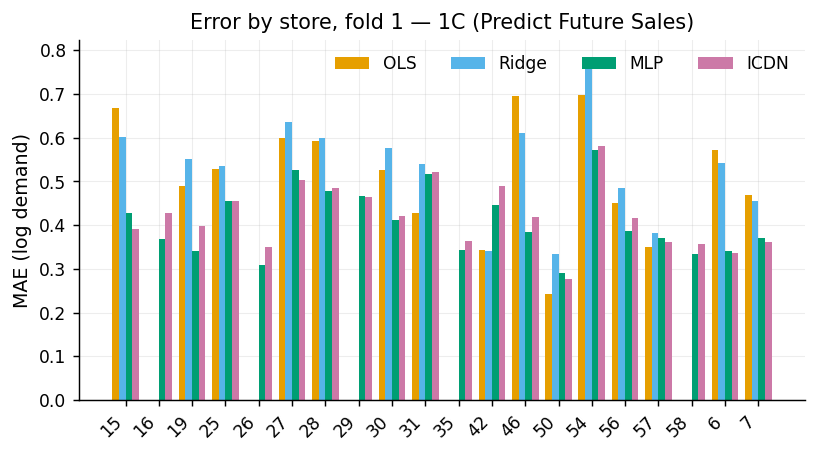

**Ten products with the largest MAE range across models (1C (Predict Future Sales), fold 1)**

,product_code,ols,n_ols,ridge,n_ridge,mlp,n_mlp,icdn,n_icdn,mae_range
0,1830,0.6297,30,0.7486,30,0.3433,164,0.3281,164,0.4204
3,3325,0.6823,23,0.5576,23,0.2690,58,0.3189,58,0.4133
7,6738,0.6114,31,0.6774,31,0.3373,154,0.3572,154,0.3401
9,7070,0.5198,46,0.4898,46,0.2926,173,0.3657,173,0.2272
2,2445,0.5352,95,0.6669,95,0.4576,214,0.4524,214,0.2145
5,6457,0.5370,80,0.6488,80,0.4489,218,0.4400,218,0.2088
6,6466,0.6163,5,0.6114,5,0.5195,57,0.4378,57,0.1785
8,6740,0.5680,17,0.4980,17,0.4080,229,0.4360,229,0.1599
4,5272,0.5956,138,0.5931,138,0.5112,259,0.5156,259,0.0845
1,2308,0.5146,148,0.4922,148,0.4597,281,0.4695,281,0.0549


  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_fold1_mae_store.pdf


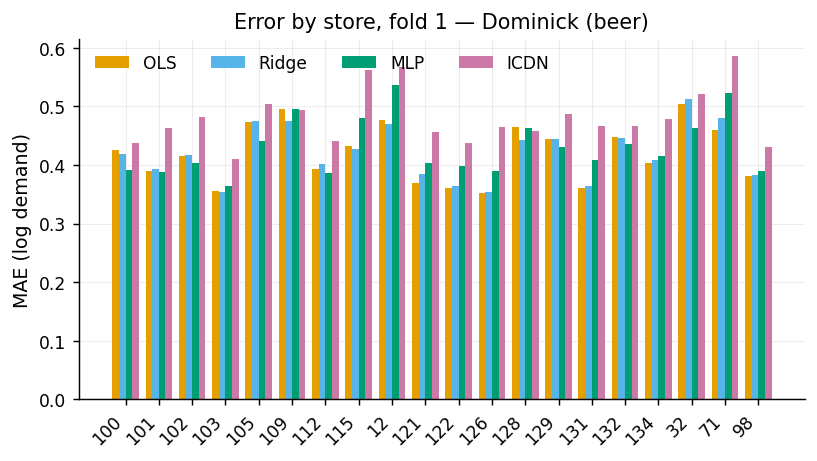

**Ten products with the largest MAE range across models (Dominick (beer), fold 1)**

,product_code,ols,n_ols,ridge,n_ridge,mlp,n_mlp,icdn,n_icdn,mae_range
11,3410017505,0.3750,720,0.3695,720,0.3690,720,0.5366,720,0.1677
9,3410015505,0.4379,705,0.4298,705,0.4465,705,0.5932,705,0.1634
15,3410057505,0.3901,719,0.3790,719,0.3925,719,0.5335,719,0.1544
18,7204001113,0.5377,688,0.5376,688,0.4962,688,0.6461,688,0.1499
17,3410057602,0.4111,718,0.4154,718,0.3905,718,0.5373,718,0.1468
1,1820000834,0.4278,704,0.4318,704,0.5604,704,0.5223,704,0.1326
19,7336011751,0.5561,681,0.5654,681,0.4431,681,0.4525,681,0.1223
12,3410017528,0.3860,719,0.3838,719,0.4057,719,0.4926,719,0.1087
16,3410057528,0.4319,716,0.4304,716,0.3872,716,0.4865,716,0.0993
14,3410057306,0.2587,720,0.2584,720,0.2969,720,0.3560,720,0.0976


In [7]:
def plot_store_mae(panel: Path, dataset: str, fold, stem: str):
    frames = []
    for model in MODEL_ORDER:
        grid = pred_cells(panel, model, fold)
        if grid.empty:
            continue
        part = error_by_group(grid, "store_code")
        part["model"] = model
        frames.append(part)
    if not frames:
        return
    df = pd.concat(frames, ignore_index=True)
    stores = sorted(df["store_code"].astype(str).unique())
    fig, ax = plt.subplots(figsize=(7.2, 3.6))
    models = [m for m in MODEL_ORDER if m in set(df["model"])]
    width = 0.8 / max(len(models), 1)
    x = np.arange(len(stores))
    for i, model in enumerate(models):
        lookup = (
            df[df["model"] == model]
            .assign(store_code=lambda x: x["store_code"].astype(str))
            .set_index("store_code")["mae"]
        )
        vals = [float(lookup.loc[s]) if s in lookup.index else np.nan for s in stores]
        ax.bar(x + (i - (len(models) - 1) / 2) * width, vals, width=width, color=COLOR[model], label=MODEL_LABEL[model])
    ax.set_xticks(x)
    ax.set_xticklabels(stores, rotation=45, ha="right")
    ax.set_ylabel("MAE (log demand)")
    ax.set_title(f"Error by store, fold {fold} — {DATASET_LABEL[dataset]}")
    ax.legend(ncol=len(models))
    savefig(fig, stem)
    plt.show()
    plt.close(fig)


def product_mae_table(panel: Path, fold) -> pd.DataFrame:
    frames = []
    for model in MODEL_ORDER:
        grid = pred_cells(panel, model, fold)
        if grid.empty:
            continue
        part = error_by_group(grid, "product_code")
        part = part.rename(columns={"mae": model})
        frames.append(part[["product_code", model, "n"]].rename(columns={"n": f"n_{model}"}))
    if not frames:
        return pd.DataFrame()
    out = frames[0]
    for part in frames[1:]:
        out = out.merge(part, on="product_code", how="outer")
    metric_cols = [m for m in MODEL_ORDER if m in out.columns]
    out["mae_range"] = out[metric_cols].max(axis=1) - out[metric_cols].min(axis=1)
    return out.sort_values("mae_range", ascending=False)


for key, panel in PANELS.items():
    kfold = load_all("kfold.csv", panel)
    folds = sorted(present_folds(kfold), key=lambda x: int(x) if str(x).isdigit() else 0)
    if not folds:
        continue
    fold = folds[0]
    plot_store_mae(panel, key, fold, f"{key}_fold{fold}_mae_store")
    prod = product_mae_table(panel, fold)
    if len(prod):
        show_table(prod.head(10), f"Ten products with the largest MAE range across models ({DATASET_LABEL[key]}, fold {fold})")


## 3. Paired ICDN–MLP predictive inference

Fold-level \(\Delta\mathrm{MAE}\) does not answer whether ICDN is predictively better on the pooled outer sample, nor with what precision. Concatenate outer-validation cells, restrict to the ICDN∩MLP intersection, and define

$$
d_{ist} = |y_{ist}-\widehat y^{\mathrm{ICDN}}_{ist}| - |y_{ist}-\widehat y^{\mathrm{MLP}}_{ist}|.
$$

A **week-block bootstrap** (block size `BLOCK_SIZE`, \(B=\) `N_BOOT_PRED_INFER` draws, no retraining) yields a percentile \(95\%\) CI for \(\Delta\mathrm{MAE}\), and the same draws for \(\Delta\mathrm{RMSE}\) and \(\Delta R^2\).

The pre-specified non-inferiority margin is \(\delta=\) `PRED_NI_MARGIN` log-demand MAE units (a design constant, not chosen after seeing the CI). Classification:

- **ICDN superior** if the CI upper bound is \(<0\);
- **MLP superior** if the CI lower bound is \(>0\);
- **ICDN non-inferior** if the upper bound is \(<\delta\) but the interval still covers \(0\);
- **indistinguishable** otherwise.

Also reported: the share of store–product series with lower MAE under ICDN, the same share weighted by cell count, and the share of cells with smaller absolute error.


**Table 5. Paired ICDN−MLP predictive inference (week-block bootstrap)**

,dataset,split,n_cells,n_series,n_weeks,n_blocks,mae_icdn,mae_mlp,delta_mae,delta_mae_ci_lo,...,delta_rmse_ci_lo,delta_rmse_ci_hi,delta_r2,delta_r2_ci_lo,delta_r2_ci_hi,share_series_icdn_better,share_series_icdn_better_weighted,share_cells_icdn_better,ni_margin,conclusion_label
0,walmart,outer,22782,200,139,7,0.4808,0.5266,-0.0459,-0.0849,...,-0.1096,-0.0032,0.0506,0.0031,0.1076,0.6750,0.6736,0.5468,0.0500,ICDN superior (95% CI for ΔMAE lies below 0)
1,walmart,holdout,8453,200,56,3,0.4456,0.5736,-0.1280,-0.1971,...,-0.1864,-0.0922,0.1101,0.0784,0.1909,0.8000,0.8023,0.6225,0.0500,ICDN superior (95% CI for ΔMAE lies below 0)
2,one_c,outer,3880,195,71,4,0.4231,0.3940,0.0291,-0.0017,...,0.0089,0.1884,-0.2121,-1.1032,-0.0325,0.3897,0.3786,0.4812,0.0500,Indistinguishable at this sample
3,one_c,holdout,903,134,29,2,0.9928,0.3226,0.6702,0.6693,...,0.8153,0.8735,-8.3408,-8.4725,-8.3061,0.1269,0.1096,0.2403,0.0500,MLP superior (95% CI for ΔMAE lies above 0)
4,dominick,outer,43285,400,110,6,0.4437,0.4483,-0.0045,-0.0343,...,-0.0321,0.0301,0.0005,-0.0215,0.0215,0.5575,0.5589,0.5081,0.0500,ICDN non-inferior (CI excludes ΔMAE ≥ δ)
5,dominick,holdout,17215,400,44,3,0.5253,0.4353,0.0900,0.0771,...,0.1039,0.2491,-0.0956,-0.1990,-0.0790,0.3075,0.3131,0.4218,0.0500,MLP superior (95% CI for ΔMAE lies above 0)


  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/paired_delta_mae_ci.pdf


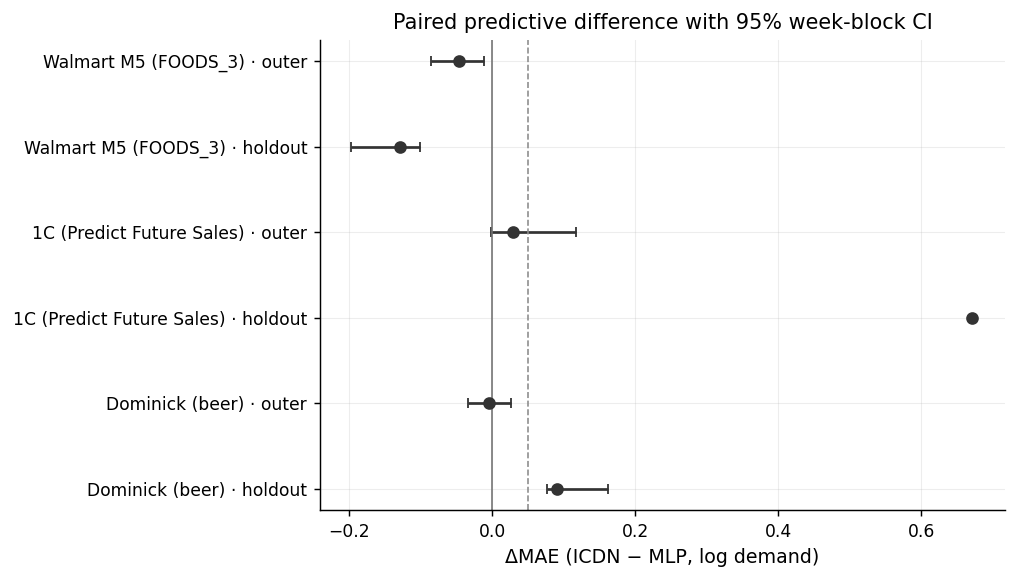

**Store–product series: median ΔMAE and share with ICDN MAE below MLP**

,dataset,split,n_series,median_delta_mae,share_icdn_better
0,dominick,holdout,400,0.0548,0.3075
1,dominick,outer,400,-0.0087,0.5575
2,one_c,holdout,134,0.5573,0.1269
3,one_c,outer,195,0.0245,0.3897
4,walmart,holdout,200,-0.0804,0.8000
5,walmart,outer,200,-0.0330,0.6750


In [8]:
pred_inf = pd.concat(
    [read_csv(p / "paired_predictive_inference.csv") for p in PANELS.values()],
    ignore_index=True,
)
pred_series = pd.concat(
    [read_csv(p / "paired_predictive_series.csv") for p in PANELS.values()],
    ignore_index=True,
)
if pred_inf.empty:
    print("paired_predictive_inference.csv missing — rebuild_all writes it from pred_cells.")
else:
    show = pred_inf.copy()
    show["conclusion_label"] = show["conclusion"].map(CONCLUSION_LABEL)
    cols = [
        "dataset", "split", "n_cells", "n_series", "n_weeks", "n_blocks",
        "mae_icdn", "mae_mlp", "delta_mae", "delta_mae_ci_lo", "delta_mae_ci_hi",
        "delta_rmse", "delta_rmse_ci_lo", "delta_rmse_ci_hi",
        "delta_r2", "delta_r2_ci_lo", "delta_r2_ci_hi",
        "share_series_icdn_better", "share_series_icdn_better_weighted",
        "share_cells_icdn_better", "ni_margin", "conclusion_label",
    ]
    show_table(show[[c for c in cols if c in show.columns]], "Table 5. Paired ICDN−MLP predictive inference (week-block bootstrap)")


def plot_delta_mae_ci(inf: pd.DataFrame, stem: str):
    df = inf.copy()
    if df.empty:
        return
    df["label"] = df["dataset"].map(DATASET_LABEL).fillna(df["dataset"]) + " · " + df["split"].astype(str)
    fig, ax = plt.subplots(figsize=(6.8, 0.55 * max(len(df), 2) + 1.4))
    y = np.arange(len(df))
    lo = df["delta_mae"] - df["delta_mae_ci_lo"]
    hi = df["delta_mae_ci_hi"] - df["delta_mae"]
    ax.errorbar(df["delta_mae"], y, xerr=np.vstack([lo, hi]), fmt="o", color="#333333", capsize=3, ms=6)
    ax.axvline(0, color="0.45", lw=0.9)
    ax.axvline(PRED_NI_MARGIN, color="0.55", lw=0.9, ls="--")
    ax.set_yticks(y)
    ax.set_yticklabels(df["label"])
    ax.set_xlabel("ΔMAE (ICDN − MLP, log demand)")
    ax.set_title("Paired predictive difference with 95% week-block CI")
    ax.invert_yaxis()
    savefig(fig, stem)
    plt.show()
    plt.close(fig)


if len(pred_inf):
    plot_delta_mae_ci(pred_inf, "paired_delta_mae_ci")
if len(pred_series):
    overview = (
        pred_series.groupby(["dataset", "split"], as_index=False)
        .agg(
            n_series=("product_code", "size"),
            median_delta_mae=("delta_mae", "median"),
            share_icdn_better=("icdn_better", "mean"),
        )
    )
    show_table(overview, "Store–product series: median ΔMAE and share with ICDN MAE below MLP")


## 4. Pairwise equations (OLS / Ridge)

`fold{k}_pred_ij.csv` stores \(\widehat y_{ijst}\) from each equation. The cell prediction is \(\widehat y_{ist}=\mathrm{mean}_j\widehat y_{ijst}\). This section audits partners per cell and that the aggregate matches `pred_cells`.


In [9]:
def audit_pred_ij(panel: Path, model: str, fold) -> pd.DataFrame | None:
    path = panel / model / (f"fold{fold}_pred_ij.csv" if str(fold) != "holdout" else "holdout_pred_ij.csv")
    cells_path = panel / model / (f"fold{fold}_pred_cells.csv" if str(fold) != "holdout" else "holdout_pred_cells.csv")
    ij = read_csv(path)
    cells = read_csv(cells_path)
    if ij.empty or cells.empty:
        return None
    agg = (
        ij.groupby(["store_code", "product_i", "week_id"], as_index=False)
        .agg(y_true=("y_true", "first"), y_pred_mean=("y_pred", "mean"), n_partners=("product_j", "nunique"), n_eq=("product_j", "size"))
        .rename(columns={"product_i": "product_code"})
    )
    merged = cells.merge(agg, on=["store_code", "product_code", "week_id"], how="inner", suffixes=("", "_ij"))
    merged["abs_gap"] = (merged["y_pred"] - merged["y_pred_mean"]).abs()
    return pd.Series({
        "dataset": merged["dataset"].iloc[0] if "dataset" in merged.columns else panel.parent.name,
        "model": model,
        "fold": fold,
        "n_eq_rows": len(ij),
        "n_cells_with_eq": len(agg),
        "n_partners_mean": float(agg["n_partners"].mean()),
        "n_partners_min": int(agg["n_partners"].min()),
        "n_partners_max": int(agg["n_partners"].max()),
        "max_abs_gap_vs_pred_cells": float(merged["abs_gap"].max()) if len(merged) else np.nan,
        "mae_from_ij": float(np.mean(np.abs(agg["y_true"] - agg["y_pred_mean"]))),
    }).to_frame().T


audits = []
for key, panel in PANELS.items():
    kfold = load_all("kfold.csv", panel)
    folds = sorted(present_folds(kfold), key=lambda x: int(x) if str(x).isdigit() else 0)
    for model in LINEAR_MODELS:
        for fold in folds:
            rec = audit_pred_ij(panel, model, fold)
            if rec is not None:
                audits.append(rec)
if audits:
    show_table(pd.concat(audits, ignore_index=True), r"Table 6. Pairwise aggregate $\widehat y_{ist}=\mathrm{mean}_j\widehat y_{ijst}$")
else:
    print("no pred_ij files")


**Table 6. Pairwise aggregate $\widehat y_{ist}=\mathrm{mean}_j\widehat y_{ijst}$**

,dataset,model,fold,n_eq_rows,n_cells_with_eq,n_partners_mean,n_partners_min,n_partners_max,max_abs_gap_vs_pred_cells,mae_from_ij
0,walmart,ols,1,93754,6941,13.507276,1,19,0.0,0.51845
1,walmart,ols,2,94938,6988,13.585861,2,19,0.0,0.564392
2,walmart,ols,3,90314,6893,13.102278,2,19,0.0,0.542507
3,walmart,ridge,1,93754,6941,13.507276,1,19,0.0,0.492567
4,walmart,ridge,2,94938,6988,13.585861,2,19,0.0,0.548468
5,walmart,ridge,3,90314,6893,13.102278,2,19,0.0,0.542194
6,one_c,ols,1,1902,613,3.102773,1,8,0.0,0.55846
7,one_c,ols,2,1924,702,2.740741,1,6,0.0,0.469956
8,one_c,ols,3,745,388,1.920103,1,5,0.0,0.481995
9,one_c,ridge,1,1902,613,3.102773,1,8,0.0,0.587739


## 5. Out-of-sample elasticities

Each row of `kfold_series.csv` is a series \((s,i,j,\mathrm{kind})\) in an outer fold. Networks average the weekly elasticity in the fold; OLS/Ridge store \(\widehat\beta\) of the equation (and `kind=own_eq` in addition to the product mean).

Economic regularity: own-price negative; cross-price in a bounded band. OLS produces extreme tails — percentiles and shares are more informative than the mean.

Boxplots clip to \([-5,5]\) (own) and \([-2,2]\) (cross) for readability. Table 8 reports how many series those windows drop, with the unclipped min and max.


In [10]:
OWN_COLS = [
    "dataset", "model", "fold","kind", "n", "mean", "median", "std", "iqr",
    "q025", "q975", "min", "max", "share_in_minus5_0", "share_positive", "share_abs_gt5",
]
CROSS_COLS = [
    "dataset", "model", "fold", "n", "mean", "median", "std", "iqr",
    "q025", "q975", "share_positive", "share_negative", "share_abs_le1", "share_abs_gt1", "share_abs_gt3",
]

series_parts = []
for p in PANELS.values():
    df = load_all("kfold_series.csv", p)
    if len(df):
        series_parts.append(df)
all_series = pd.concat(series_parts, ignore_index=True) if series_parts else pd.DataFrame()
if "outer_fold" not in all_series.columns and "fold" in all_series.columns:
    all_series["outer_fold"] = all_series["fold"]

elast_tab = elasticity_distribution(all_series)
if elast_tab.empty:
    print("no kfold_series.csv")
else:
    own = elast_tab[elast_tab["kind"].astype(str).isin(["own", "own_eq"])]
    cross = elast_tab[elast_tab["kind"].astype(str) == "cross"]
    if len(own):
        show_table(own[[c for c in OWN_COLS if c in own.columns]].sort_values(["dataset", "fold", "kind", "model"]),
                   "Table 7a. Own-price OOS distribution (native set)")
    if len(cross):
        show_table(cross[[c for c in CROSS_COLS if c in cross.columns]].sort_values(["dataset", "fold", "model"]),
                   "Table 7b. Cross-price OOS distribution (native set)")


**Table 7a. Own-price OOS distribution (native set)**

,dataset,model,fold,kind,n,mean,median,std,iqr,q025,q975,min,max,share_in_minus5_0,share_positive,share_abs_gt5
1,dominick,icdn,1,own,400,-2.4105,-2.3869,0.2314,0.3267,-2.9849,-2.0787,-3.1568,-2.0168,1.0000,0.0000,0.0000
7,dominick,mlp,1,own,400,-0.9525,-0.9713,0.5587,0.6990,-2.2488,-0.0639,-2.6856,0.0205,0.9900,0.0100,0.0000
13,dominick,ols,1,own,400,-4.6362,-4.7733,2.1362,2.7168,-8.1443,0.0852,-9.5990,5.3074,0.5250,0.0300,0.4475
22,dominick,ridge,1,own,400,-3.6763,-3.5204,2.0096,2.6834,-7.6635,0.0477,-9.3248,2.3866,0.7325,0.0275,0.2400
14,dominick,ols,1,own_eq,7113,-4.6342,-4.7543,2.2322,2.7717,-8.3773,0.2934,-17.9761,7.5530,0.5216,0.0292,0.4511
23,dominick,ridge,1,own_eq,7113,-3.6685,-3.4879,2.1189,2.9054,-7.9120,0.2162,-10.2677,6.5937,0.7013,0.0351,0.2639
3,dominick,icdn,2,own,400,-2.7293,-2.6287,0.4351,0.5792,-3.8665,-2.1045,-4.1824,-1.9897,1.0000,0.0000,0.0000
9,dominick,mlp,2,own,400,-0.8232,-0.9475,0.4803,0.7465,-1.7702,0.0009,-1.9725,0.2631,0.9725,0.0275,0.0000
16,dominick,ols,2,own,400,-4.7676,-4.7342,1.8500,2.2996,-8.1461,-1.4402,-10.3519,5.1300,0.5500,0.0075,0.4450
25,dominick,ridge,2,own,400,-3.9323,-3.8126,1.8019,2.3249,-7.8845,-0.8224,-9.6639,3.4413,0.7375,0.0075,0.2550


**Table 7b. Cross-price OOS distribution (native set)**

,dataset,model,fold,n,mean,median,std,iqr,q025,q975,share_positive,share_negative,share_abs_le1,share_abs_gt1,share_abs_gt3
0,dominick,icdn,1,1200,0.5457,0.6200,0.2897,0.4681,-0.0463,0.9553,0.9558,0.0442,0.9917,0.0083,0.0000
6,dominick,mlp,1,7600,-0.0430,-0.0034,0.3011,0.2869,-0.9635,0.4044,0.4930,0.5070,0.9791,0.0209,0.0000
12,dominick,ols,1,7113,0.2727,0.1431,1.4460,1.2022,-2.2190,3.9334,0.5681,0.4319,0.7087,0.2913,0.0586
21,dominick,ridge,1,7113,0.0131,-0.0122,1.1572,0.9052,-2.2630,2.6297,0.4914,0.5086,0.7849,0.2151,0.0335
2,dominick,icdn,2,800,0.5193,0.4861,0.3334,0.3652,-0.0725,1.3733,0.9712,0.0288,0.9337,0.0663,0.0000
8,dominick,mlp,2,7600,-0.0351,0.0036,0.2850,0.2694,-0.9466,0.4015,0.5082,0.4918,0.9783,0.0217,0.0000
15,dominick,ols,2,7099,0.1633,0.1601,1.3044,1.0094,-2.7911,2.7632,0.5933,0.4067,0.7539,0.2461,0.0424
24,dominick,ridge,2,7099,0.0035,0.0491,1.1465,0.8547,-2.6867,1.9191,0.5351,0.4649,0.7976,0.2024,0.0299
4,dominick,icdn,3,800,-0.1388,-0.0613,0.2750,0.1577,-0.8323,0.3081,0.1875,0.8125,0.9812,0.0187,0.0000
10,dominick,mlp,3,7600,-0.0384,-0.0020,0.3268,0.2816,-1.0521,0.4784,0.4968,0.5032,0.9730,0.0270,0.0000


**Table 8. Boxplot clipping audit (n_clipped / share_clipped vs unclipped min–max)**

,dataset,model,kind,n,min_full,max_full,clip_lo,clip_hi,n_clipped,share_clipped
0,dominick,icdn,cross,2800,-1.2568,2.0984,-1.0000,1.0000,78,0.0279
2,dominick,mlp,cross,22800,-1.9721,0.7819,-1.0000,1.0000,529,0.0232
4,dominick,ols,cross,21363,-13.4501,13.6588,-1.0000,1.0000,5631,0.2636
6,dominick,ridge,cross,21363,-13.4375,13.0554,-1.0000,1.0000,4502,0.2107
1,dominick,icdn,own,1200,-4.1824,-1.9603,-5.0000,0.0000,0,0.0000
3,dominick,mlp,own,1200,-2.6856,0.2631,-5.0000,0.0000,15,0.0125
5,dominick,ols,own,1200,-10.3519,5.3074,-5.0000,0.0000,562,0.4683
7,dominick,ridge,own,1200,-9.6639,3.7877,-5.0000,0.0000,337,0.2808
8,one_c,icdn,cross,1366,-0.6973,3.8797,-2.0000,2.0000,26,0.0190
10,one_c,mlp,cross,3058,-0.2922,0.3128,-2.0000,2.0000,0,0.0000


  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_own_box.pdf


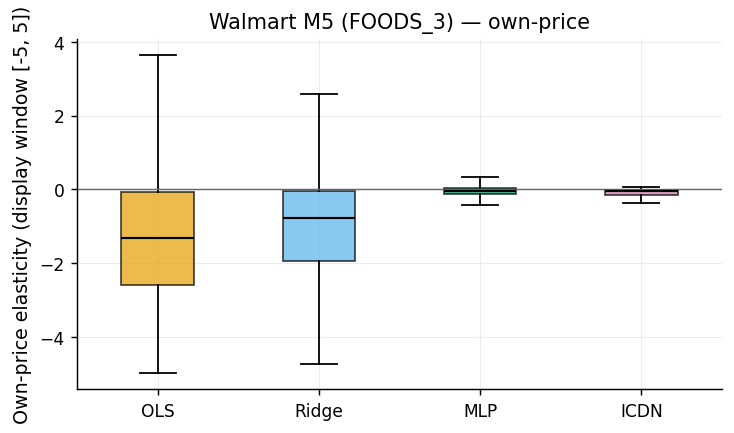

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_cross_box.pdf


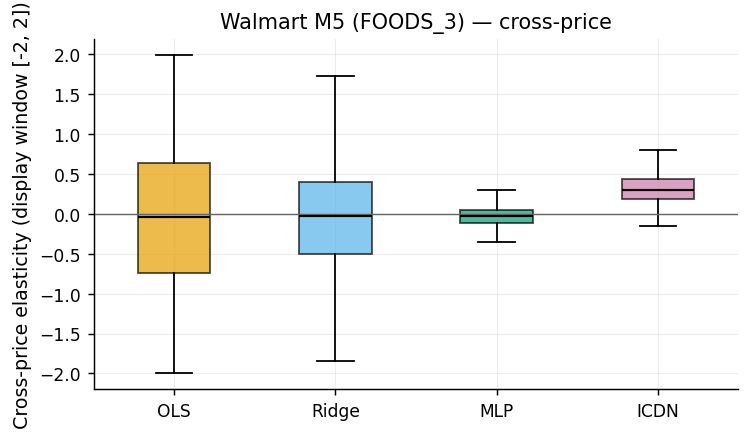

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/one_c_own_box.pdf


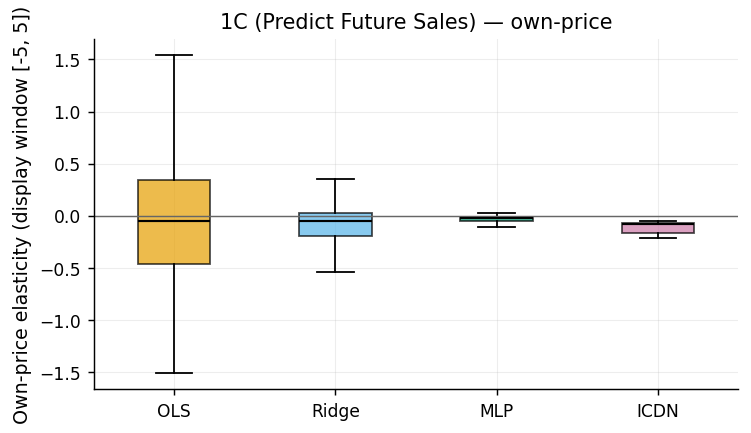

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/one_c_cross_box.pdf


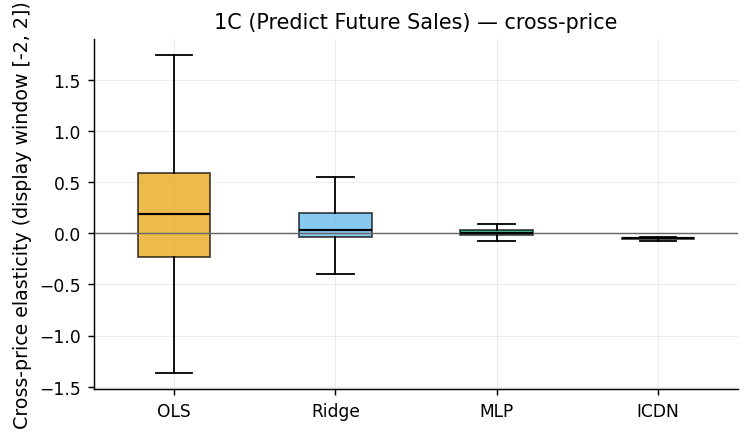

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_own_box.pdf


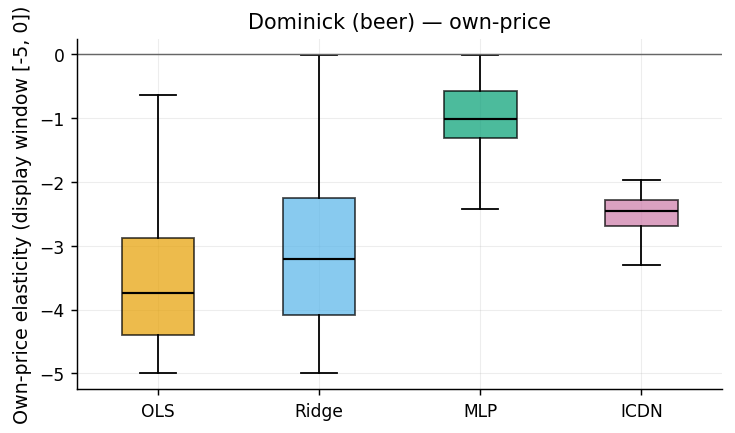

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_cross_box.pdf


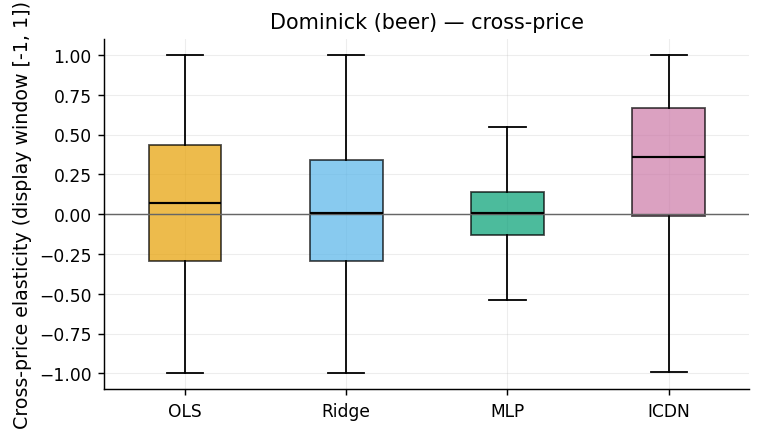

In [11]:
def plot_elasticity_box(series: pd.DataFrame, dataset: str, kind: str, stem: str, clip=None):
    df = series[(series["dataset"] == dataset) & (series["kind"] == kind)].copy()
    if df.empty:
        return
    df["elasticity"] = pd.to_numeric(df["elasticity"], errors="coerce")
    plotted = df
    if clip is not None:
        plotted = df[(df["elasticity"] >= clip[0]) & (df["elasticity"] <= clip[1])]
    fig, ax = plt.subplots(figsize=(6.4, 3.5))
    data, labels, colors = [], [], []
    for model in MODEL_ORDER:
        part = plotted[plotted["model"] == model]["elasticity"].dropna()
        if part.empty:
            continue
        data.append(part.to_numpy())
        labels.append(MODEL_LABEL[model])
        colors.append(COLOR[model])
    if not data:
        return
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, medianprops={"color": "black", "linewidth": 1.2})
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.axhline(0, color="0.4", lw=0.8)
    ylab = KIND_LABEL.get(kind, kind).capitalize() + " elasticity"
    if clip is not None:
        ylab += f" (display window [{clip[0]:.0f}, {clip[1]:.0f}])"
    ax.set_ylabel(ylab)
    ax.set_title(f"{DATASET_LABEL[dataset]} — {KIND_LABEL.get(kind, kind)}")
    savefig(fig, stem)
    plt.show()
    plt.close(fig)


if len(all_series):
    clip_parts = []
    for ds, sub in all_series[all_series["kind"].isin(["own", "cross"])].groupby("dataset"):
        clip_parts.append(elasticity_clip_diagnostics(sub, clips_for(ds)))
    clip_tab = pd.concat(clip_parts, ignore_index=True) if clip_parts else pd.DataFrame()
    if len(clip_tab):
        show_table(
            clip_tab.sort_values(["dataset", "kind", "model"]),
            "Table 8. Boxplot clipping audit (n_clipped / share_clipped vs unclipped min–max)",
        )
    for key in PANELS:
        sub = all_series[all_series["dataset"] == key]
        if sub.empty:
            continue
        clip = clips_for(key)
        plot_elasticity_box(all_series, key, "own", f"{key}_own_box", clip=clip["own"])
        plot_elasticity_box(all_series, key, "cross", f"{key}_cross_box", clip=clip["cross"])


## 6. Temporal stability (`kfold_series_stats`)

`fold_sd` is the SD of the **same** series across outer folds. `fold_range` is \(\max-\min\). `sign_stable=1` if the sign does not flip (zeros ignored). `dominant_sign_share` is the majority-sign fraction.

The headline cross-price reproducibility result is not that native set. An edge must appear in all \(N_{\mathrm{FOLDS}}\) outer folds **and** on the same fold IDs in both models of the comparison (ICDN∩MLP, ICDN∩Ridge, ICDN∩OLS). That is `edge_matched_kfold_sd.csv` (`stability_set=all_folds`).

Coverage is separate in `edge_matched_kfold_coverage.csv`: presence frequency, edges in every fold, edges in at least two folds, and `n_edges_stable` (the full intersection).


In [12]:
stats_parts = []
for p in PANELS.values():
    df = load_all("kfold_series_stats.csv", p)
    if len(df):
        stats_parts.append(df)
all_stats = pd.concat(stats_parts, ignore_index=True) if stats_parts else pd.DataFrame()


def stats_overview(stats: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (dataset, model, kind), part in stats.groupby(["dataset", "model", "kind"]):
        sd = pd.to_numeric(part["fold_sd"], errors="coerce")
        rng = pd.to_numeric(part.get("fold_range"), errors="coerce") if "fold_range" in part.columns else pd.Series(dtype=float)
        rows.append({
            "dataset": dataset, "model": model, "kind": kind,
            "n_series": len(part),
            "median_n_folds": float(part["n_folds"].median()) if "n_folds" in part.columns else np.nan,
            "median_fold_sd": float(sd.median()),
            "median_fold_range": float(rng.median()) if len(rng) else np.nan,
            "share_sign_stable": float(pd.to_numeric(part["sign_stable"], errors="coerce").mean()) if "sign_stable" in part.columns else np.nan,
            "median_dominant_sign_share": float(pd.to_numeric(part.get("dominant_sign_share"), errors="coerce").median()) if "dominant_sign_share" in part.columns else np.nan,
        })
    out = pd.DataFrame(rows)
    out["model"] = pd.Categorical(out["model"], MODEL_ORDER, ordered=True)
    return out.sort_values(["dataset", "kind", "model"])


if len(all_stats):
    show_table(stats_overview(all_stats), "Table 9. Temporal stability by model (native set)")

cov_parts, sd_parts = [], []
for p in PANELS.values():
    cov_parts.append(read_csv(p / "edge_matched_kfold_coverage.csv"))
    sd_parts.append(read_csv(p / "edge_matched_kfold_sd.csv"))
edge_cov = pd.concat([x for x in cov_parts if len(x)], ignore_index=True) if any(len(x) for x in cov_parts) else pd.DataFrame()
edge_sd = pd.concat([x for x in sd_parts if len(x)], ignore_index=True) if any(len(x) for x in sd_parts) else pd.DataFrame()

if edge_cov.empty:
    print("edge_matched_kfold_coverage.csv missing.")
else:
    show_table(edge_cov.sort_values(["dataset", "eval", "model"]), "Table 9b. Edge coverage across folds")

if edge_sd.empty:
    print("edge_matched_kfold_sd.csv empty (no edges in all folds with the same IDs).")
else:
    show_table(edge_sd.sort_values(["dataset", "eval", "model"]), "Table 9c. fold_sd on the complete set (n_folds = N_FOLDS, same IDs)")


**Table 9. Temporal stability by model (native set)**

,dataset,model,kind,n_series,median_n_folds,median_fold_sd,median_fold_range,share_sign_stable,median_dominant_sign_share
4,dominick,ols,cross,7197,3.0000,0.2723,0.5134,0.6853,1.0000
7,dominick,ridge,cross,7197,3.0000,0.2540,0.4753,0.6649,1.0000
2,dominick,mlp,cross,7600,3.0000,0.1050,0.2008,0.5807,1.0000
0,dominick,icdn,cross,1720,1.0000,0.4089,0.0000,0.6244,1.0000
5,dominick,ols,own,400,3.0000,0.4750,0.9080,0.9575,1.0000
8,dominick,ridge,own,400,3.0000,0.6600,1.2727,0.9625,1.0000
3,dominick,mlp,own,400,3.0000,0.1691,0.3266,0.9700,1.0000
1,dominick,icdn,own,400,3.0000,0.1670,0.3170,1.0000,1.0000
6,dominick,ols,own_eq,7197,3.0000,0.4958,0.9363,0.9582,1.0000
9,dominick,ridge,own_eq,7197,3.0000,0.7309,1.3577,0.9600,1.0000


**Table 9b. Edge coverage across folds**

,dataset,eval,model,kind,n_protocol_folds,n_edges,n_edges_all_folds,n_edges_at_least_2,mean_presence_freq,median_n_folds,n_edges_stable
20,dominick,matched_icdn_mlp,icdn,cross,3,1720,280,800,0.5426,1.0000,280
21,dominick,matched_icdn_mlp,mlp,cross,3,1720,280,800,0.5426,1.0000,280
22,dominick,matched_icdn_ols,icdn,cross,3,1595,258,739,0.5417,1.0000,258
23,dominick,matched_icdn_ols,ols,cross,3,1595,258,739,0.5417,1.0000,258
24,dominick,matched_icdn_ridge,icdn,cross,3,1595,258,739,0.5417,1.0000,258
25,dominick,matched_icdn_ridge,ridge,cross,3,1595,258,739,0.5417,1.0000,258
26,dominick,native,icdn,cross,3,1720,280,800,0.5426,1.0000,280
27,dominick,native,mlp,cross,3,7600,7600,7600,1.0000,3.0000,7600
28,dominick,native,ols,cross,3,7197,7059,7107,0.9894,3.0000,7059
29,dominick,native,ridge,cross,3,7197,7059,7107,0.9894,3.0000,7059


**Table 9c. fold_sd on the complete set (n_folds = N_FOLDS, same IDs)**

,dataset,eval,model,kind,n_series,n_series_sd,n_folds,cross_mean,cross_fold_sd,share_sign_stable,n_protocol_folds,stability_set
20,dominick,matched_icdn_mlp,icdn,cross,280,280,3,0.3359,0.5541,0.2179,3,all_folds
21,dominick,matched_icdn_mlp,mlp,cross,280,280,3,0.0950,0.1225,0.6607,3,all_folds
22,dominick,matched_icdn_ols,icdn,cross,258,258,3,0.3200,0.5649,0.1705,3,all_folds
23,dominick,matched_icdn_ols,ols,cross,258,258,3,0.2132,1.0937,0.6628,3,all_folds
24,dominick,matched_icdn_ridge,icdn,cross,258,258,3,0.3200,0.5649,0.1705,3,all_folds
25,dominick,matched_icdn_ridge,ridge,cross,258,258,3,-0.2291,1.0582,0.6589,3,all_folds
26,dominick,native,icdn,cross,280,280,3,0.3359,0.5541,0.2179,3,all_folds
27,dominick,native,mlp,cross,7600,7600,3,-0.0388,0.1195,0.5807,3,all_folds
28,dominick,native,ols,cross,7059,7059,3,0.1653,0.5038,0.6803,3,all_folds
29,dominick,native,ridge,cross,7059,7059,3,0.0064,0.4470,0.6606,3,all_folds


## 7. Weekly elasticities (MLP / ICDN)

`fold{k}_elasticities_long.csv` unpacks the fold mean into weeks, with `observed_i` and `observed_j`. `share_obs_both` is \(P(\mathrm{observed}_i\land\mathrm{observed}_j)\), not the product of the two marginal shares.

If the file is missing, skip this section and re-run MLP/ICDN.


**Table 10. Within-fold weekly heterogeneity (MLP/ICDN)**

,dataset,model,fold,kind,n_rows,share_positive,p05,p50,p95,p995,share_obs_both
0,dominick,icdn,1,cross,41785,0.8640,-0.2877,0.7061,0.9898,1.1563,1.0000
1,dominick,icdn,1,own,14188,0.0000,-2.9083,-2.3718,-2.0781,-1.9895,1.0000
2,dominick,icdn,2,cross,28068,0.9647,0.0034,0.5158,1.1451,2.0372,1.0000
3,dominick,icdn,2,own,14246,0.0000,-3.6382,-2.6207,-2.1468,-1.9865,1.0000
4,dominick,icdn,3,cross,29426,0.3299,-0.9261,-0.0517,0.4149,0.7920,1.0000
5,dominick,icdn,3,own,14851,0.0000,-3.0027,-2.3996,-2.0464,-1.9259,1.0000
6,dominick,mlp,1,cross,265660,0.4914,-0.6658,-0.0054,0.4123,0.6723,1.0000
7,dominick,mlp,1,own,14188,0.0144,-2.0039,-0.9301,-0.0864,0.0625,1.0000
8,dominick,mlp,2,cross,267818,0.4982,-0.6150,-0.0011,0.3917,0.6453,1.0000
9,dominick,mlp,2,own,14246,0.0344,-1.6719,-0.8942,-0.0444,0.2410,1.0000


  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_own_positive_week.pdf


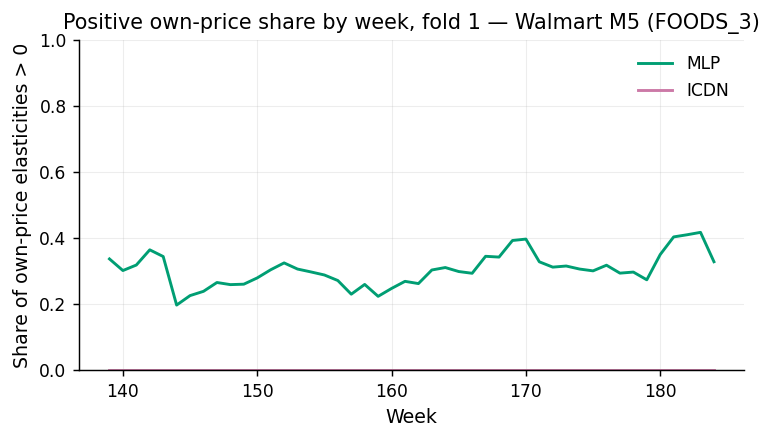

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/one_c_own_positive_week.pdf


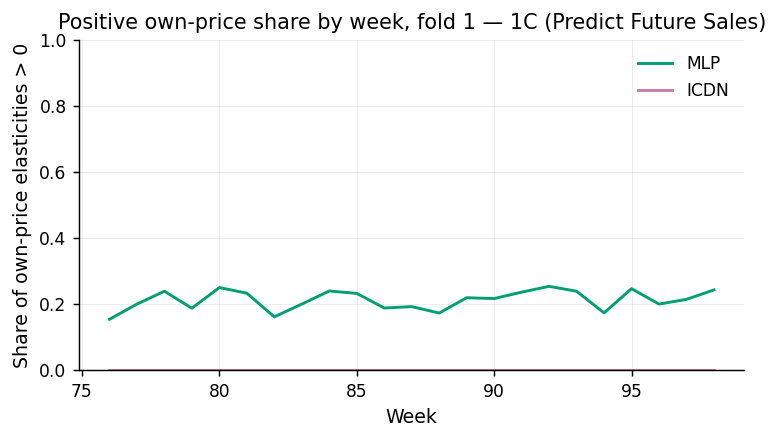

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_own_positive_week.pdf


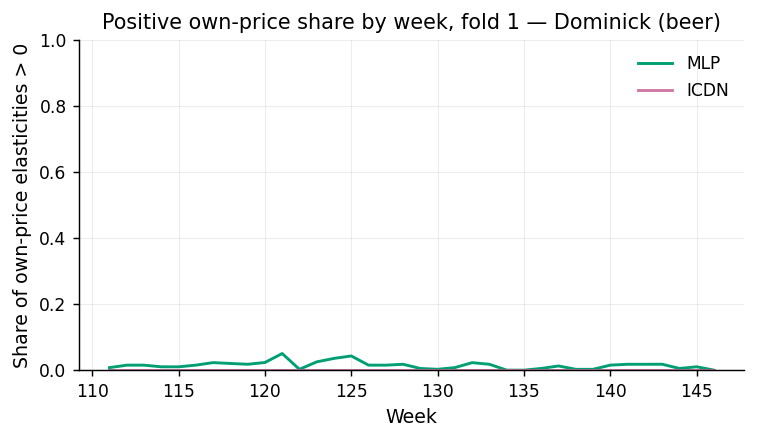

In [13]:
def load_long(panel: Path) -> pd.DataFrame:
    parts = []
    for model in NEURAL_MODELS:
        for path in sorted((panel / model).glob("fold*_elasticities_long.csv")):
            parts.append(read_csv(path))
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


def long_overview(long: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (dataset, model, fold, kind), part in long.groupby(["dataset", "model", "outer_fold", "kind"]):
        e = pd.to_numeric(part["elasticity"], errors="coerce").dropna()
        rows.append({
            "dataset": dataset, "model": model, "fold": fold, "kind": kind,
            "n_rows": int(len(e)),
            "share_positive": float((e > 0).mean()),
            "p05": float(e.quantile(0.05)),
            "p50": float(e.quantile(0.50)),
            "p95": float(e.quantile(0.95)),
            "p995": float(e.quantile(0.995)),
            "share_obs_both": share_obs_both(part),
        })
    return pd.DataFrame(rows)


long_parts = [load_long(p) for p in PANELS.values()]
all_long = pd.concat([x for x in long_parts if len(x)], ignore_index=True) if any(len(x) for x in long_parts) else pd.DataFrame()
if all_long.empty:
    print("No fold*_elasticities_long.csv. Produced on the next MLP/ICDN run.")
else:
    show_table(long_overview(all_long), "Table 10. Within-fold weekly heterogeneity (MLP/ICDN)")

    def plot_own_share_week(long: pd.DataFrame, dataset: str, fold, stem: str):
        df = long[(long["dataset"] == dataset) & (long["outer_fold"].astype(str) == str(fold)) & (long["kind"] == "own")].copy()
        if df.empty:
            return
        fig, ax = plt.subplots(figsize=(6.6, 3.3))
        for model in NEURAL_MODELS:
            part = df[df["model"] == model]
            if part.empty:
                continue
            g = part.groupby("week_id")["elasticity"].apply(lambda s: float((s > 0).mean()))
            ax.plot(g.index, g.values, color=COLOR[model], label=MODEL_LABEL[model], lw=1.6)
        ax.set_xlabel("Week")
        ax.set_ylabel("Share of own-price elasticities > 0")
        ax.set_ylim(0, 1)
        ax.set_title(f"Positive own-price share by week, fold {fold} — {DATASET_LABEL[dataset]}")
        ax.legend()
        savefig(fig, stem)
        plt.show()
        plt.close(fig)

    for key, panel in PANELS.items():
        kfold = load_all("kfold.csv", panel)
        folds = sorted(present_folds(kfold), key=lambda x: int(x) if str(x).isdigit() else 0)
        if folds:
            plot_own_share_week(all_long, key, folds[0], f"{key}_own_positive_week")


## 8. Matched-edge elasticities

`matched_elasticity_series.csv` aligns ICDN with MLP, Ridge, and OLS on common keys \((s,i,j,\mathrm{kind})\). Sign agreement and absolute difference do not mix distinct neighbourhoods. Protocol `edge_matched_*.csv` tables remain the mean summary; here the pair cloud is visible.


**Table 11. Matched-edge agreement (ICDN vs MLP / Ridge / OLS)**

,dataset,fold,model_a,model_b,kind,n_common,share_same_sign,median_abs_diff,mean_a,mean_b
0,dominick,1,icdn,mlp,cross,1200,0.6050,0.5110,0.5457,0.0035
2,dominick,1,icdn,ols,cross,1103,0.5902,0.7766,0.5588,0.4541
4,dominick,1,icdn,ridge,cross,1103,0.5331,0.6787,0.5588,0.1151
1,dominick,1,icdn,mlp,own,400,0.9900,1.5335,-2.4105,-0.9525
3,dominick,1,icdn,ols,own,400,0.9700,2.4188,-2.4105,-4.6362
...,...,...,...,...,...,...,...,...,...,...
68,walmart,holdout,icdn,ols,cross,280,0.5750,1.1422,0.3405,-3.3546
70,walmart,holdout,icdn,ridge,cross,280,0.6071,0.7169,0.3405,-0.3523
67,walmart,holdout,icdn,mlp,own,200,0.6200,0.1560,-0.1013,-0.0159
69,walmart,holdout,icdn,ols,own,191,0.7120,2.0656,-0.1010,1.0744


  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_matched_own_scatter.pdf


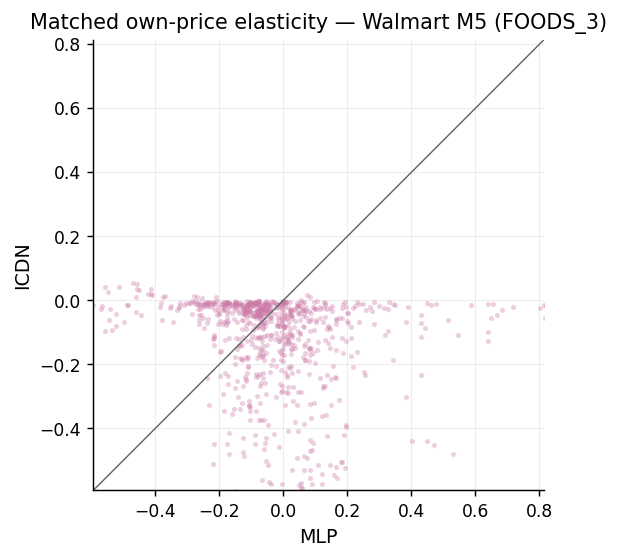

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_matched_cross_scatter.pdf


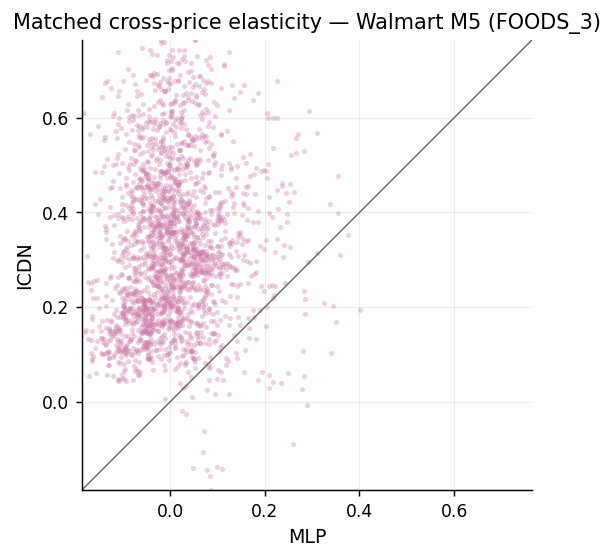

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/one_c_matched_own_scatter.pdf


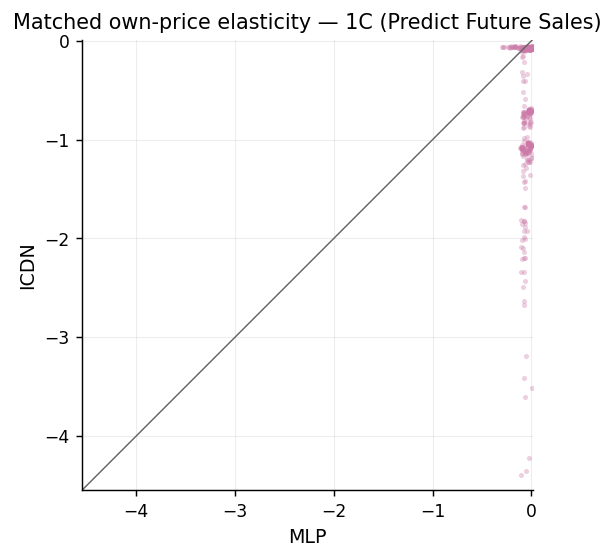

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/one_c_matched_cross_scatter.pdf


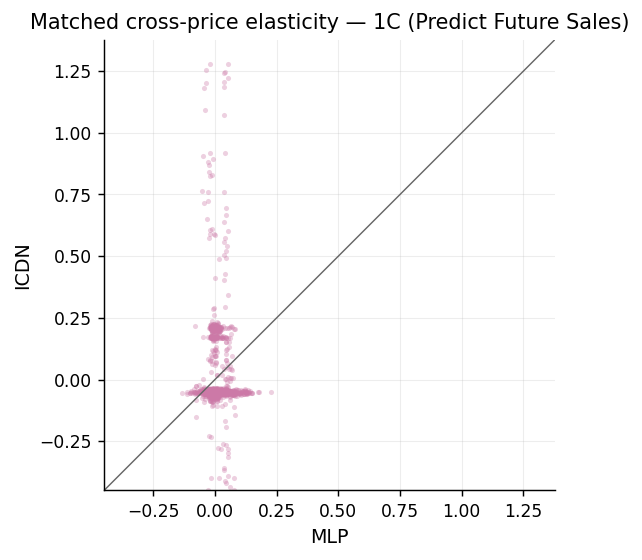

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_matched_own_scatter.pdf


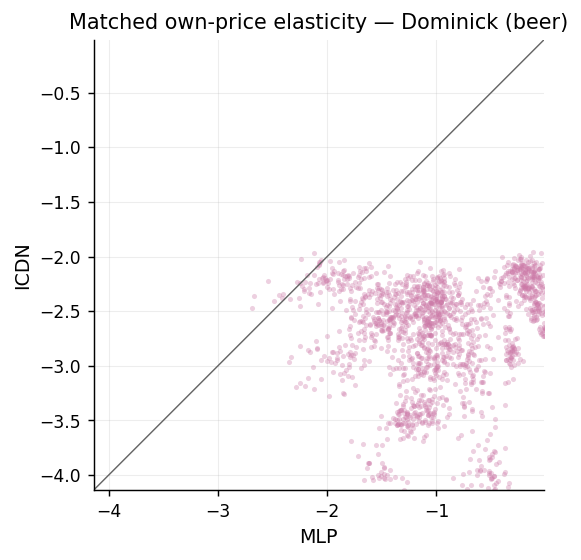

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_matched_cross_scatter.pdf


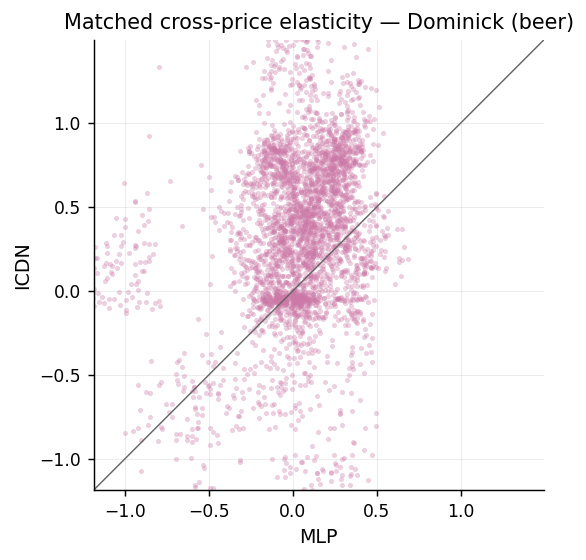

In [14]:
matched_e = pd.concat(
    [read_csv(p / "matched_elasticity_series.csv") for p in PANELS.values()],
    ignore_index=True,
)


def matched_agreement(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (dataset, fold, a, b, kind), part in df.groupby(["dataset", "fold", "model_a", "model_b", "kind"]):
        d = pd.to_numeric(part["absolute_difference"], errors="coerce")
        rows.append({
            "dataset": dataset, "fold": fold, "model_a": a, "model_b": b, "kind": kind,
            "n_common": len(part),
            "share_same_sign": float(part["same_sign"].mean()) if "same_sign" in part.columns else np.nan,
            "median_abs_diff": float(d.median()),
            "mean_a": float(part["elasticity_a"].mean()),
            "mean_b": float(part["elasticity_b"].mean()),
        })
    return pd.DataFrame(rows).sort_values(["dataset", "fold", "kind", "model_b"])


if matched_e.empty:
    print("no matched_elasticity_series.csv")
else:
    show_table(matched_agreement(matched_e), "Table 11. Matched-edge agreement (ICDN vs MLP / Ridge / OLS)")


def plot_icdn_mlp_scatter(df: pd.DataFrame, dataset: str, kind: str, stem: str):
    part = df[(df["dataset"] == dataset) & (df["kind"] == kind) & (df["model_a"] == "icdn") & (df["model_b"] == "mlp")]
    if part.empty:
        return
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.scatter(part["elasticity_b"], part["elasticity_a"], s=8, alpha=0.35, c=COLOR["icdn"], linewidths=0)
    lim = np.nanpercentile(np.r_[part["elasticity_a"], part["elasticity_b"]], [1, 99])
    ax.plot(lim, lim, color="0.4", lw=0.8)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel("MLP")
    ax.set_ylabel("ICDN")
    ax.set_title(f"Matched {KIND_LABEL.get(kind, kind)} elasticity — {DATASET_LABEL[dataset]}")
    ax.set_aspect("equal", "box")
    savefig(fig, stem)
    plt.show()
    plt.close(fig)


if len(matched_e):
    for key in PANELS:
        plot_icdn_mlp_scatter(matched_e, key, "own", f"{key}_matched_own_scatter")
        plot_icdn_mlp_scatter(matched_e, key, "cross", f"{key}_matched_cross_scatter")


## 9. Holdout

The holdout is the point estimate contrasted with the bootstrap. `holdout_pred_cells.csv` is the common grid for that window. Point elasticities are in `holdout_elasticities.csv`.


In [15]:
hold_parts = []
for p in PANELS.values():
    df = load_all("holdout_elasticities.csv", p)
    if len(df):
        hold_parts.append(df)
hold = pd.concat(hold_parts, ignore_index=True) if hold_parts else pd.DataFrame()
if hold.empty:
    print("no holdout_elasticities")
else:
    hold = hold.copy()
    hold["outer_fold"] = "holdout"
    hold_dist = elasticity_distribution(hold)
    own = hold_dist[hold_dist["kind"].astype(str).isin(["own", "own_eq"])]
    cross = hold_dist[hold_dist["kind"].astype(str) == "cross"]
    if len(own):
        show_table(own[[c for c in OWN_COLS if c in own.columns]], "Table 12a. Holdout own-price elasticities")
    if len(cross):
        show_table(cross[[c for c in CROSS_COLS if c in cross.columns]], "Table 12b. Holdout cross-price elasticities")

hold_pred = matched_pred[matched_pred["fold"].astype(str) == "holdout"] if len(matched_pred) else pd.DataFrame()
if len(hold_pred):
    show_table(
        hold_pred[["dataset", "model_a", "model_b", "n_common_cells", "mae_a", "mae_b", "rmse_a", "rmse_b", "r2_a", "r2_b", "delta_mae"]],
        "Table 13. Matched-cell prediction on the holdout",
    )


**Table 12a. Holdout own-price elasticities**

,dataset,model,fold,kind,n,mean,median,std,iqr,q025,q975,min,max,share_in_minus5_0,share_positive,share_abs_gt5
1,dominick,icdn,holdout,own,400,-3.3275,-3.3376,0.5066,0.7378,-4.3022,-2.4765,-4.4638,-2.4068,1.0000,0.0000,0.0000
3,dominick,mlp,holdout,own,400,-1.0353,-1.1187,0.5902,0.8862,-2.1236,-0.0081,-2.3485,0.0854,0.9800,0.0200,0.0000
5,dominick,ols,holdout,own,400,-4.7290,-4.8699,1.9298,2.3363,-8.2728,-0.0929,-9.5537,4.3663,0.5000,0.0225,0.4775
6,dominick,ols,holdout,own_eq,7151,-4.7154,-4.8426,2.0011,2.4542,-8.3566,0.0972,-10.2200,7.8289,0.5104,0.0262,0.4640
8,dominick,ridge,holdout,own,400,-3.9746,-3.9574,1.9276,2.4158,-8.0595,-0.0726,-9.4980,4.2479,0.6825,0.0225,0.2950
9,dominick,ridge,holdout,own_eq,7151,-3.9583,-3.9026,2.0306,2.6043,-8.2289,-0.0898,-10.0564,7.8054,0.6880,0.0158,0.2963
11,one_c,icdn,holdout,own,134,-1.7179,-1.0899,1.3703,0.5566,-5.8183,-1.0333,-6.8561,-1.0274,0.9254,0.0000,0.0746
13,one_c,mlp,holdout,own,134,-0.0444,-0.0346,0.0321,0.0503,-0.1041,-0.0009,-0.1137,0.0089,0.9776,0.0224,0.0000
15,one_c,ols,holdout,own,76,-0.0327,-0.0220,0.6120,0.5826,-1.4496,0.9593,-1.6481,2.1869,0.5263,0.4737,0.0000
16,one_c,ols,holdout,own_eq,267,0.0716,0.0498,0.6864,0.7168,-1.2055,1.5687,-1.9194,2.8281,0.4569,0.5431,0.0000


**Table 12b. Holdout cross-price elasticities**

,dataset,model,fold,n,mean,median,std,iqr,q025,q975,share_positive,share_negative,share_abs_le1,share_abs_gt1,share_abs_gt3
0,dominick,icdn,holdout,800,0.2990,0.2724,0.8332,1.1326,-1.2919,1.7076,0.7025,0.2975,0.6675,0.3325,0.0000
2,dominick,mlp,holdout,7600,-0.0251,0.0107,0.3187,0.3141,-1.0334,0.4378,0.5188,0.4812,0.9736,0.0264,0.0000
4,dominick,ols,holdout,7151,0.0699,0.0976,1.5380,1.0141,-3.2593,2.6828,0.5528,0.4472,0.7456,0.2544,0.0495
7,dominick,ridge,holdout,7151,0.0035,0.0156,1.2991,0.8249,-2.9428,2.3069,0.5085,0.4915,0.7916,0.2084,0.0390
10,one_c,icdn,holdout,249,-0.0774,0.1233,0.6161,0.2858,-1.5748,0.2216,0.6627,0.3373,0.9518,0.0482,0.0120
12,one_c,mlp,holdout,568,0.0081,0.0045,0.0403,0.0397,-0.0822,0.0834,0.5810,0.4190,1.0000,0.0000,0.0000
14,one_c,ols,holdout,267,0.1854,0.2463,0.6204,0.7985,-1.0133,1.2312,0.6330,0.3670,0.9064,0.0936,0.0000
17,one_c,ridge,holdout,267,0.1127,0.0547,0.3451,0.3137,-0.6814,0.8138,0.6854,0.3146,0.9813,0.0187,0.0000
20,walmart,icdn,holdout,400,0.3562,0.3583,0.1963,0.2733,0.0161,0.6782,0.9750,0.0250,1.0000,0.0000,0.0000
22,walmart,mlp,holdout,3800,-0.0310,-0.0230,0.1793,0.1795,-0.4220,0.3186,0.4295,0.5705,0.9992,0.0008,0.0000


**Table 13. Matched-cell prediction on the holdout**

,dataset,model_a,model_b,n_common_cells,mae_a,mae_b,rmse_a,rmse_b,r2_a,r2_b,delta_mae
18,walmart,icdn,mlp,8453,0.4456,0.5736,0.6393,0.7584,0.7297,0.6196,-0.1280
19,walmart,icdn,ridge,8007,0.4475,0.5525,0.6443,0.7823,0.7346,0.6087,-0.1050
20,walmart,icdn,ols,8007,0.4475,0.5542,0.6443,0.7896,0.7346,0.6014,-0.1067
21,walmart,mlp,ridge,8007,0.5740,0.5525,0.7619,0.7823,0.6289,0.6087,0.0215
22,walmart,mlp,ols,8007,0.5740,0.5542,0.7619,0.7896,0.6289,0.6014,0.0198
23,walmart,ridge,ols,8007,0.5525,0.5542,0.7823,0.7896,0.6087,0.6014,-0.0017
42,one_c,icdn,mlp,903,0.9928,0.3226,1.2579,0.3978,-8.2674,0.0734,0.6702
43,one_c,icdn,ridge,453,0.9060,0.4744,1.1054,0.5616,-5.4667,-0.6690,0.4315
44,one_c,icdn,ols,453,0.9060,0.4873,1.1054,0.6055,-5.4667,-0.9407,0.4186
45,one_c,mlp,ridge,453,0.3409,0.4744,0.4124,0.5616,0.0999,-0.6690,-0.1336


## 10. Bootstrap uncertainty

Each row of `bootstrap.csv` is a refit on non-overlapping blocks. `n_attempted` / `n_successful` document universe failures; replicas are not dropped silently.

`bootstrap_series_ci.csv` is the distribution **conditional** on the series appearing in that replica. `ci_width=q_{0.975}-q_{0.025}`. `bootstrap_matched.csv` keeps `freq ≥ 0.8`.

`bootstrap_matched_global.csv` is a descriptive summary by `kind` (median widths, median SD). It is **not** a CI for a global parameter.

Separate medians of ICDN and MLP SDs do not answer: *on the same series, how often is ICDN more stable?* That is the paired table below.


In [16]:
boot_parts = []
for p in PANELS.values():
    df = load_all("bootstrap.csv", p)
    if len(df):
        boot_parts.append(df)
boots = pd.concat(boot_parts, ignore_index=True) if boot_parts else pd.DataFrame()
if boots.empty:
    print("no bootstrap.csv")
else:
    cols = [c for c in [
        "dataset", "model", "boot", "mae_val", "rmse_val", "r2_val", "n_cells",
        "n_own", "n_cross", "own_mean", "cross_mean", "fit_seconds",
        "n_attempted", "n_successful",
    ] if c in boots.columns]
    show_table(boots[cols].sort_values(["dataset", "model", "boot"]), "Table 14. Bootstrap replicates (global behaviour)")

    fail = boots.groupby(["dataset", "model"], as_index=False).agg(
        n_successful=("boot", "nunique"),
        n_attempted=("n_attempted", "max"),
        mae_mean=("mae_val", "mean"),
        mae_sd=("mae_val", "std"),
    )
    fail["fail_rate"] = 1 - fail["n_successful"] / fail["n_attempted"].replace(0, np.nan)
    show_table(fail, "Table 15. Failure rate and predictive stability across replicates")


**Table 14. Bootstrap replicates (global behaviour)**

,dataset,model,boot,mae_val,rmse_val,r2_val,n_cells,n_own,n_cross,own_mean,cross_mean,fit_seconds,n_attempted,n_successful
1100,dominick,icdn,0,0.5356,0.6509,0.7481,17215,400,800,-3.3073,0.2629,20.8337,100,100
1101,dominick,icdn,1,0.4884,0.6097,0.7790,17215,400,800,-2.6040,0.6001,14.5123,100,100
1102,dominick,icdn,2,0.4755,0.5940,0.7902,17215,400,800,-3.7933,0.3873,28.0880,100,100
1103,dominick,icdn,3,0.5630,0.6843,0.7215,17215,400,800,-3.7188,0.2839,28.6602,100,100
1104,dominick,icdn,4,0.6247,0.7808,0.6374,17215,400,800,-2.9755,0.9018,10.5729,100,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,walmart,ridge,95,0.5912,0.8369,0.5522,8007,191,3192,0.2387,-0.5467,42.5785,100,100
196,walmart,ridge,96,0.4948,0.6821,0.6538,6285,146,2000,-3.9310,-2.2601,40.6160,100,100
197,walmart,ridge,97,0.5253,0.7435,0.6455,7822,185,3015,0.7526,-0.6455,42.2731,100,100
198,walmart,ridge,98,0.5411,0.7568,0.6328,7822,185,2990,0.2116,-0.5802,41.8183,100,100


**Table 15. Failure rate and predictive stability across replicates**

,dataset,model,n_successful,n_attempted,mae_mean,mae_sd,fail_rate
0,dominick,icdn,100,100,0.5419,0.1133,0.0000
1,dominick,mlp,100,100,0.4885,0.1348,0.0000
2,dominick,ols,100,100,0.4993,0.0161,0.0000
3,dominick,ridge,100,100,0.4863,0.0135,0.0000
4,one_c,icdn,100,100,0.7334,0.7602,0.0000
5,one_c,mlp,100,100,0.4135,0.1391,0.0000
6,one_c,ols,100,100,26.4224,77.2853,0.0000
7,one_c,ridge,100,100,3.7723,9.6751,0.0000
8,walmart,icdn,100,100,0.5450,0.0939,0.0000
9,walmart,mlp,100,100,0.5483,0.2520,0.0000


In [17]:
ci_parts = []
glob_parts = []
for p in PANELS.values():
    ci = load_all("bootstrap_series_ci.csv", p)
    if len(ci):
        ci_parts.append(ci)
    g = load_all("bootstrap_matched_global.csv", p)
    if len(g):
        if "dataset" not in g.columns:
            ds = (load_all("kfold.csv", p)["dataset"].iloc[0] if len(load_all("kfold.csv", p)) else p.parent.name)
            g = g.assign(dataset=ds)
        glob_parts.append(g)
all_ci = pd.concat(ci_parts, ignore_index=True) if ci_parts else pd.DataFrame()
all_glob = pd.concat(glob_parts, ignore_index=True) if glob_parts else pd.DataFrame()
if len(all_glob):
    show_table(all_glob, "Table 16. Matched bootstrap summary by kind (not a global CI)")


def ci_overview(ci: pd.DataFrame) -> pd.DataFrame:
    rows = []
    keep = ci[ci["matched"] == True] if "matched" in ci.columns else ci
    for (dataset, model, kind), part in keep.groupby(["dataset", "model", "kind"]):
        w = pd.to_numeric(part.get("ci_width"), errors="coerce")
        sd = pd.to_numeric(part.get("sd"), errors="coerce")
        rows.append({
            "dataset": dataset, "model": model, "kind": kind,
            "n_matched": len(part),
            "median_sd": float(sd.median()),
            "median_ci_width": float(w.median()) if w.notna().any() else np.nan,
            "median_share_positive": float(pd.to_numeric(part.get("share_positive"), errors="coerce").median()) if "share_positive" in part.columns else np.nan,
            "mean_freq": float(part["freq"].mean()) if "freq" in part.columns else np.nan,
        })
    out = pd.DataFrame(rows)
    out["model"] = pd.Categorical(out["model"], MODEL_ORDER, ordered=True)
    return out.sort_values(["dataset", "kind", "model"])


if len(all_ci):
    show_table(ci_overview(all_ci), "Table 17. Series-level uncertainty (matched only, freq ≥ 0.8)")


**Table 16. Matched bootstrap summary by kind (not a global CI)**

,kind,n_series,mean_freq,mean_conditional,median_width,median_sd,model,dataset
0,cross,2703,0.9598,-1.3733,5.1485,1.4001,ols,walmart
1,own,181,0.9792,1.4285,6.1568,1.7023,ols,walmart
2,own_eq,2703,0.9598,1.1433,6.7699,1.8298,ols,walmart
3,cross,2703,0.9598,-0.2836,2.6604,0.7211,ridge,walmart
4,own,181,0.9792,1.0385,3.0858,0.8741,ridge,walmart
5,own_eq,2703,0.9598,0.7812,3.3172,0.8970,ridge,walmart
6,cross,3800,1.0000,0.0010,0.6715,0.1808,mlp,walmart
7,own,200,1.0000,0.1118,0.6369,0.1774,mlp,walmart
8,cross,220,0.9136,0.4099,0.6841,0.1735,icdn,walmart
9,own,200,1.0000,-0.1265,0.2614,0.0775,icdn,walmart


**Table 17. Series-level uncertainty (matched only, freq ≥ 0.8)**

,dataset,model,kind,n_matched,median_sd,median_ci_width,median_share_positive,mean_freq
4,dominick,ols,cross,6787,0.4894,1.8528,0.5700,0.9784
7,dominick,ridge,cross,6787,0.4031,1.5182,0.5109,0.9784
2,dominick,mlp,cross,7600,0.2459,0.9277,0.5300,1.0000
0,dominick,icdn,cross,40,0.2471,0.9057,0.9551,0.8500
5,dominick,ols,own,390,0.9921,3.7129,0.0000,0.9835
8,dominick,ridge,own,390,0.6642,2.4714,0.0000,0.9835
3,dominick,mlp,own,400,0.3688,1.4455,0.0100,1.0000
1,dominick,icdn,own,400,0.3514,1.3407,0.0000,1.0000
6,dominick,ols,own_eq,6787,1.0140,3.8275,0.0000,0.9784
9,dominick,ridge,own_eq,6787,0.6963,2.5732,0.0000,0.9784


  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_boot_width_own.pdf


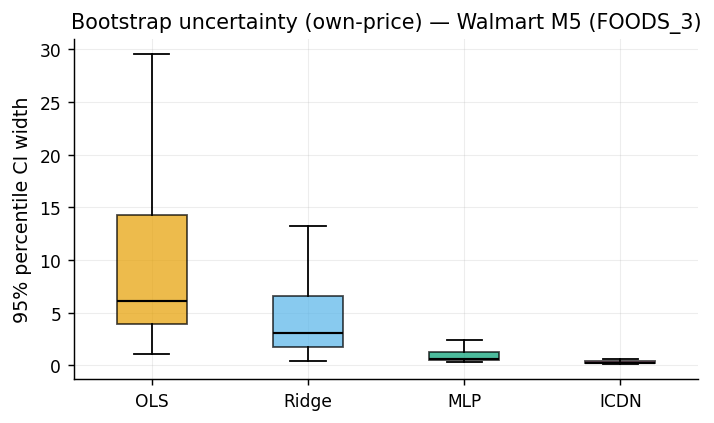

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_boot_width_cross.pdf


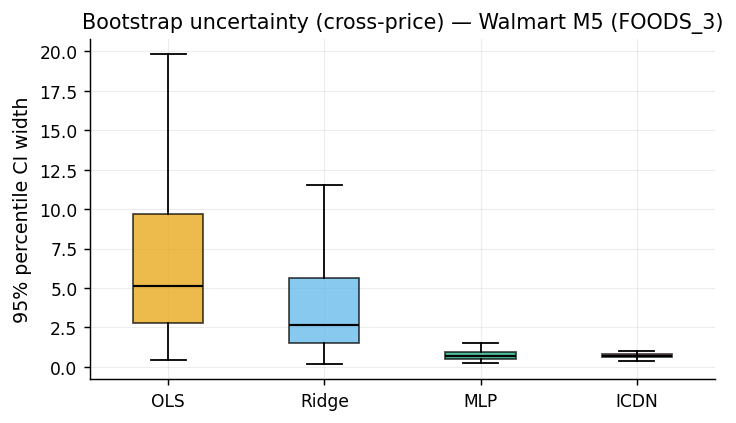

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/one_c_boot_width_own.pdf


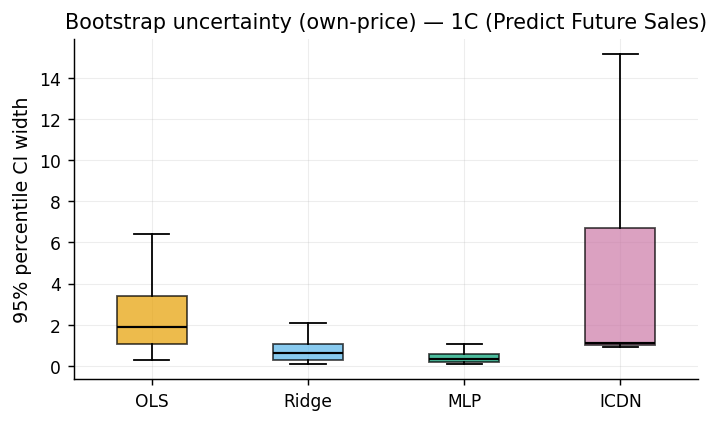

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/one_c_boot_width_cross.pdf


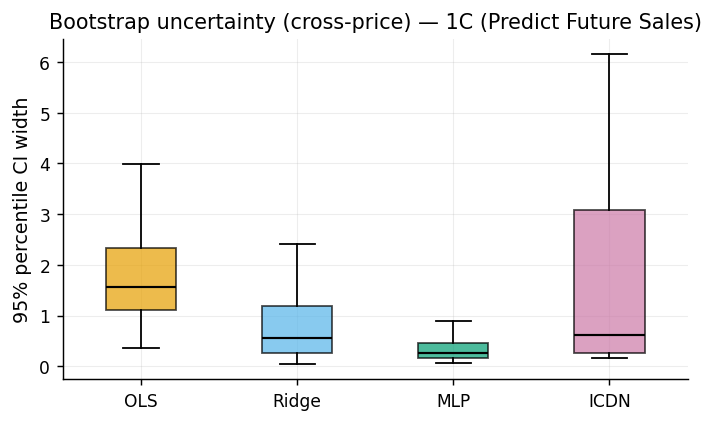

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_boot_width_own.pdf


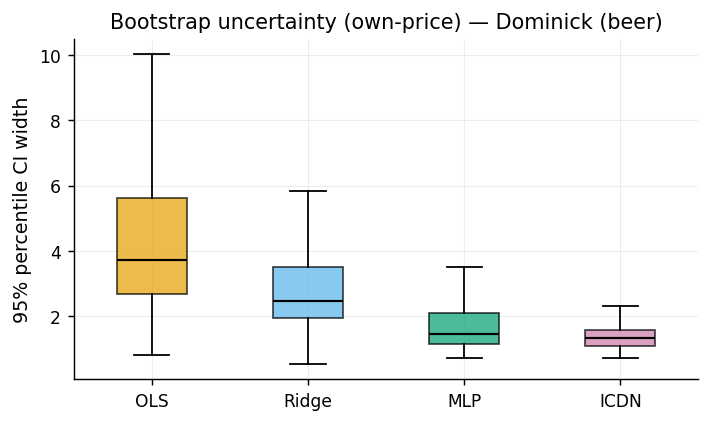

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_boot_width_cross.pdf


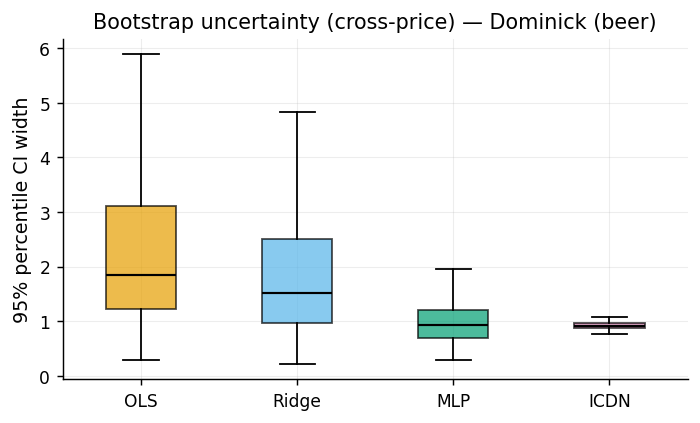

In [18]:
def plot_ci_width(ci: pd.DataFrame, dataset: str, kind: str, stem: str):
    df = ci[(ci["dataset"] == dataset) & (ci["kind"] == kind)].copy()
    if "matched" in df.columns:
        df = df[df["matched"] == True]
    if df.empty or "ci_width" not in df.columns:
        return
    fig, ax = plt.subplots(figsize=(6.2, 3.4))
    data, labels, colors = [], [], []
    for model in MODEL_ORDER:
        part = pd.to_numeric(df.loc[df["model"] == model, "ci_width"], errors="coerce").dropna()
        if part.empty:
            continue
        data.append(part.to_numpy())
        labels.append(MODEL_LABEL[model])
        colors.append(COLOR[model])
    if not data:
        return
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, medianprops={"color": "black", "linewidth": 1.2})
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_ylabel("95% percentile CI width")
    ax.set_title(f"Bootstrap uncertainty ({KIND_LABEL.get(kind, kind)}) — {DATASET_LABEL[dataset]}")
    savefig(fig, stem)
    plt.show()
    plt.close(fig)


if len(all_ci):
    for key in PANELS:
        plot_ci_width(all_ci, key, "own", f"{key}_boot_width_own")
        plot_ci_width(all_ci, key, "cross", f"{key}_boot_width_cross")


### Paired ICDN–MLP bootstrap stability

Join `bootstrap_replicates.csv` on `(bootstrap_id, store_code, product_i, product_j, kind)` and keep **exactly the common bootstrap IDs of each series**. Then

$$
\mathrm{SD}^{\mathrm{boot}}_{\mathrm{ICDN}},\quad \mathrm{SD}^{\mathrm{boot}}_{\mathrm{MLP}},\quad
W^{\mathrm{boot}}_{\mathrm{ICDN}},\quad W^{\mathrm{boot}}_{\mathrm{MLP}}
$$

are computed on that intersection. Report, separately for own- and cross-price,

$$
P(\mathrm{SD}^{\mathrm{boot}}_{\mathrm{ICDN}}<\mathrm{SD}^{\mathrm{boot}}_{\mathrm{MLP}}),\quad
P(W^{\mathrm{boot}}_{\mathrm{ICDN}}<W^{\mathrm{boot}}_{\mathrm{MLP}}),\quad
\mathrm{median}(\mathrm{SD}^{\mathrm{boot}}_{\mathrm{ICDN}}-\mathrm{SD}^{\mathrm{boot}}_{\mathrm{MLP}}).
$$

Each series row stores `n_common_bootstrap_ids` and `common_bootstrap_frequency`. For ICDN **cross-price**, `edge_selection_frequency` is the share of ICDN replicates in which the edge is selected. That is a different component of uncertainty from the SD of the elasticity when the edge exists.


**Table 18. Paired ICDN–MLP bootstrap stability (common replicate IDs)**

,dataset,kind,n_series,n_series_sd_defined,p_sd_icdn_lt_mlp,p_width_icdn_lt_mlp,median_sd_diff,median_width_diff,median_n_common_bootstrap_ids,mean_common_bootstrap_frequency,mean_edge_selection_frequency,median_edge_selection_frequency
0,walmart,cross,1900,1450,0.3455,0.3517,0.0449,0.1375,4.0000,0.2105,0.2105,0.0400
1,walmart,own,200,200,0.9250,0.9350,-0.0784,-0.3428,100.0000,1.0000,—,—
2,one_c,cross,544,521,0.1267,0.1267,0.1445,0.3992,15.0000,0.4443,0.4443,0.1500
3,one_c,own,134,134,0.0000,0.0000,0.3404,0.8469,100.0000,1.0000,—,—
4,dominick,cross,3960,3380,0.3938,0.3811,0.0692,0.2080,8.0000,0.2020,0.2020,0.0800
5,dominick,own,400,400,0.4450,0.4700,0.0179,0.0195,100.0000,1.0000,—,—


**paired_bootstrap_stability.csv (first rows; one row per series)**

,dataset,store_code,product_i,product_j,kind,n_common_bootstrap_ids,common_bootstrap_frequency,edge_selection_frequency,sd_icdn,sd_mlp,sd_diff,width_icdn,width_mlp
0,walmart,CA_1,FOODS_3_041,FOODS_3_041,own,100,1.0000,1.0000,0.0924,0.1216,-0.0292,0.2525,0.4364
1,walmart,CA_1,FOODS_3_041,FOODS_3_098,cross,86,0.8600,0.8600,0.7773,0.1415,0.6358,3.3520,0.5081
2,walmart,CA_1,FOODS_3_041,FOODS_3_615,cross,34,0.3400,0.3400,0.4387,0.0937,0.3450,1.6244,0.2891
3,walmart,CA_1,FOODS_3_098,FOODS_3_041,cross,94,0.9400,0.9400,0.2387,0.1066,0.1320,0.9485,0.4148
4,walmart,CA_1,FOODS_3_098,FOODS_3_098,own,100,1.0000,1.0000,0.1005,0.1201,-0.0195,0.3992,0.4383
5,walmart,CA_1,FOODS_3_098,FOODS_3_448,cross,85,0.8500,0.8500,0.1307,0.0752,0.0554,0.4907,0.3260
6,walmart,CA_1,FOODS_3_115,FOODS_3_041,cross,93,0.9300,0.9300,0.2321,0.1175,0.1146,0.9438,0.4530
7,walmart,CA_1,FOODS_3_115,FOODS_3_098,cross,33,0.3300,0.3300,0.3565,0.1160,0.2405,1.3955,0.3811


  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_paired_boot_sd_own.pdf


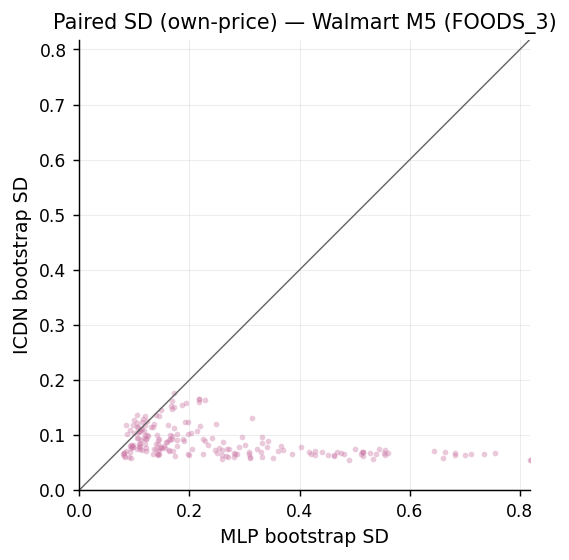

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_paired_boot_sd_cross.pdf


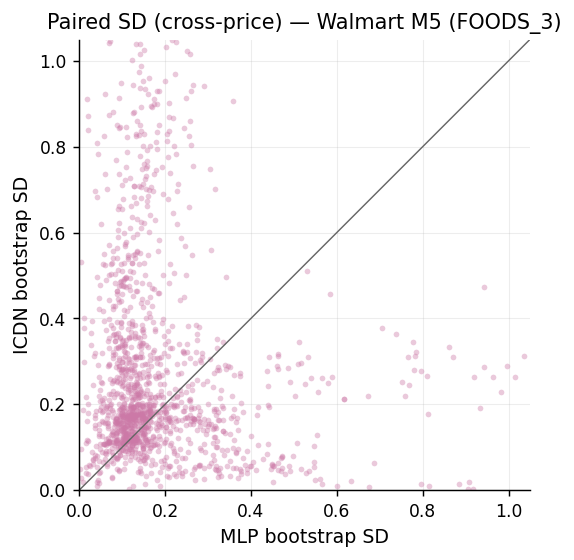

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/one_c_paired_boot_sd_own.pdf


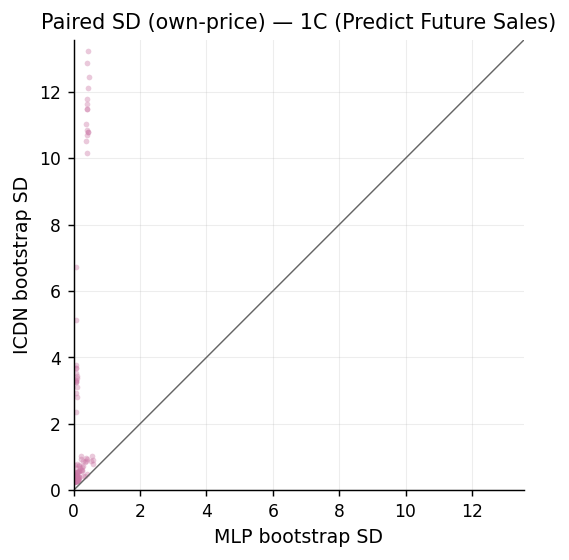

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/one_c_paired_boot_sd_cross.pdf


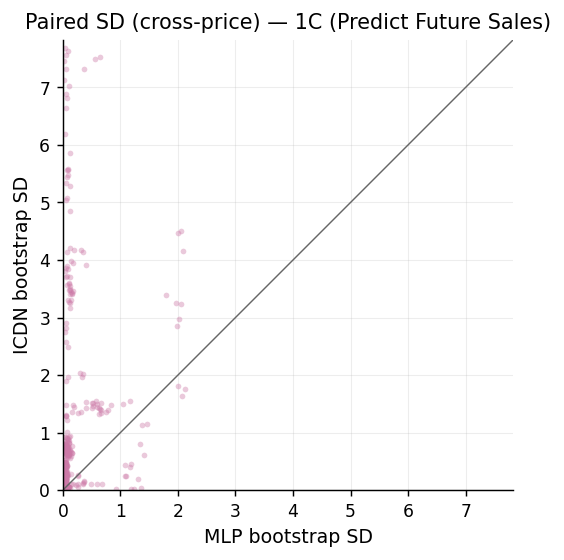

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_paired_boot_sd_own.pdf


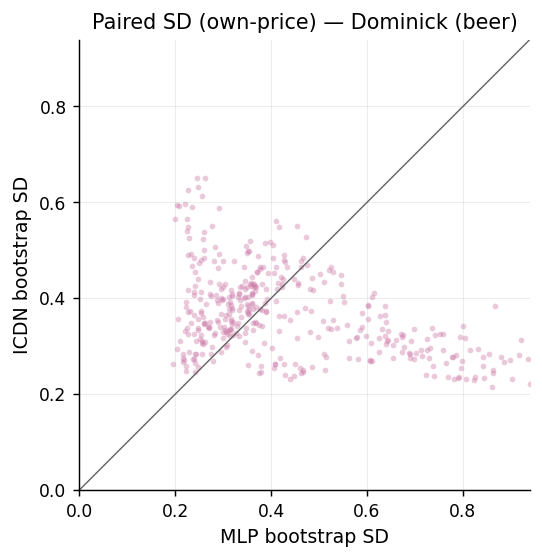

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_paired_boot_sd_cross.pdf


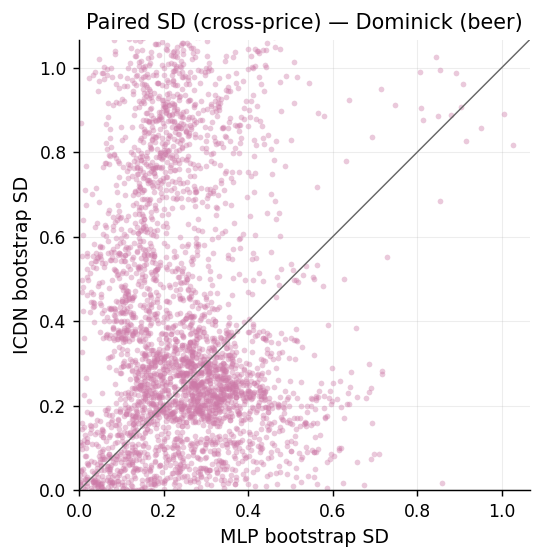

In [19]:
stab = pd.concat(
    [read_csv(p / "paired_bootstrap_stability.csv") for p in PANELS.values()],
    ignore_index=True,
)
stab_sum = pd.concat(
    [read_csv(p / "paired_bootstrap_summary.csv") for p in PANELS.values()],
    ignore_index=True,
)
if stab_sum.empty:
    print("paired_bootstrap_summary.csv missing.")
else:
    show_table(stab_sum, "Table 18. Paired ICDN–MLP bootstrap stability (common replicate IDs)")
if len(stab):
    show_table(
        stab.head(8)[[c for c in [
            "dataset", "store_code", "product_i", "product_j", "kind",
            "n_common_bootstrap_ids", "common_bootstrap_frequency", "edge_selection_frequency",
            "sd_icdn", "sd_mlp", "sd_diff", "width_icdn", "width_mlp",
        ] if c in stab.columns]],
        "paired_bootstrap_stability.csv (first rows; one row per series)",
    )


def plot_paired_sd(series: pd.DataFrame, dataset: str, kind: str, stem: str):
    part = series[(series["dataset"] == dataset) & (series["kind"] == kind)].dropna(subset=["sd_icdn", "sd_mlp"])
    if part.empty:
        return
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.scatter(part["sd_mlp"], part["sd_icdn"], s=10, alpha=0.4, c=COLOR["icdn"], linewidths=0)
    hi = np.nanpercentile(np.r_[part["sd_icdn"], part["sd_mlp"]], 99)
    ax.plot([0, hi], [0, hi], color="0.4", lw=0.8)
    ax.set_xlim(0, hi)
    ax.set_ylim(0, hi)
    ax.set_xlabel("MLP bootstrap SD")
    ax.set_ylabel("ICDN bootstrap SD")
    ax.set_title(f"Paired SD ({KIND_LABEL.get(kind, kind)}) — {DATASET_LABEL[dataset]}")
    ax.set_aspect("equal", "box")
    savefig(fig, stem)
    plt.show()
    plt.close(fig)


if len(stab):
    for key in PANELS:
        plot_paired_sd(stab, key, "own", f"{key}_paired_boot_sd_own")
        plot_paired_sd(stab, key, "cross", f"{key}_paired_boot_sd_cross")


### Holdout inside the bootstrap CI, boot/fold SD ratio, folds inside the CI

`holdout_in_boot_ci.csv` asks whether the holdout point lies in \([q_{0.025}, q_{0.975}]\) of its series. `boot_fold_ratio.csv` compares bootstrap SD with temporal SD; `zero_fold_sd_flag` marks series with no fold variation. `fold_in_boot_ci.csv` is the share of outer-fold estimates inside the bootstrap interval.


In [20]:
def rate_table(df: pd.DataFrame, flag: str, extra_group=()) -> pd.DataFrame:
    keys = ["dataset", "model", "kind", *extra_group]
    keys = [k for k in keys if k in df.columns]
    rows = []
    for key, part in df.groupby(keys):
        rec = dict(zip(keys, key if isinstance(key, tuple) else (key,)))
        rec["n"] = len(part)
        rec["share"] = float(part[flag].mean())
        rows.append(rec)
    return pd.DataFrame(rows)


hold_ci_parts, ratio_parts, fold_ci_parts = [], [], []
for p in PANELS.values():
    a = load_all("holdout_in_boot_ci.csv", p)
    if len(a):
        hold_ci_parts.append(a)
    b = load_all("boot_fold_ratio.csv", p)
    if len(b):
        ratio_parts.append(b)
    c = load_all("fold_in_boot_ci.csv", p)
    if len(c):
        fold_ci_parts.append(c)
hold_ci = pd.concat(hold_ci_parts, ignore_index=True) if hold_ci_parts else pd.DataFrame()
ratio = pd.concat(ratio_parts, ignore_index=True) if ratio_parts else pd.DataFrame()
fold_ci = pd.concat(fold_ci_parts, ignore_index=True) if fold_ci_parts else pd.DataFrame()

if len(hold_ci) and "in_boot_ci" in hold_ci.columns:
    show_table(rate_table(hold_ci, "in_boot_ci"), "Table 19. Share of holdout points inside the bootstrap CI")
if len(fold_ci) and "inside_boot_ci" in fold_ci.columns:
    show_table(rate_table(fold_ci, "inside_boot_ci", extra_group=("outer_fold",)), "Table 20. Share of fold elasticities inside the bootstrap CI")
if len(ratio):
    overview = []
    for (dataset, model, kind), part in ratio.groupby(["dataset", "model", "kind"]):
        r = pd.to_numeric(part.get("sd_ratio_boot_fold"), errors="coerce")
        r = r.replace([np.inf, -np.inf], np.nan)
        overview.append({
            "dataset": dataset, "model": model, "kind": kind,
            "n": len(part),
            "median_sd_ratio": float(r.median()),
            "share_zero_fold_sd": float(part["zero_fold_sd_flag"].mean()) if "zero_fold_sd_flag" in part.columns else np.nan,
        })
    show_table(pd.DataFrame(overview).sort_values(["dataset", "kind", "model"]),
               "Table 21. Bootstrap SD / between-fold SD (matched series)")


**Table 19. Share of holdout points inside the bootstrap CI**

,dataset,model,kind,n,share
0,dominick,icdn,cross,40,1.0000
1,dominick,icdn,own,400,0.9425
2,dominick,mlp,cross,7600,0.9858
3,dominick,mlp,own,400,1.0000
4,dominick,ols,cross,6787,1.0000
5,dominick,ols,own,390,1.0000
6,dominick,ols,own_eq,6787,1.0000
7,dominick,ridge,cross,6787,1.0000
8,dominick,ridge,own,390,1.0000
9,dominick,ridge,own_eq,6787,1.0000


**Table 20. Share of fold elasticities inside the bootstrap CI**

,dataset,model,kind,outer_fold,n,share
0,dominick,icdn,cross,1,80,0.3250
1,dominick,icdn,own,1,400,0.2375
2,dominick,icdn,own,2,400,0.7900
3,dominick,icdn,own,3,400,0.3050
4,dominick,mlp,cross,1,7600,0.9414
...,...,...,...,...,...,...
83,walmart,ridge,own,2,191,0.8953
84,walmart,ridge,own,3,191,1.0000
85,walmart,ridge,own_eq,1,2593,0.7270
86,walmart,ridge,own_eq,2,3180,0.9003


/home/thebigmonster/Github/nn-elasticity-additional-work/venv-icdn/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


**Table 21. Bootstrap SD / between-fold SD (matched series)**

,dataset,model,kind,n,median_sd_ratio,share_zero_fold_sd
0,dominick,icdn,cross,40,—,1.0000
2,dominick,mlp,cross,7600,2.3002,0.0000
4,dominick,ols,cross,6787,1.7571,0.0090
7,dominick,ridge,cross,6787,1.5869,0.0090
1,dominick,icdn,own,400,1.9503,0.0000
3,dominick,mlp,own,400,2.1848,0.0000
5,dominick,ols,own,390,2.0305,0.0000
8,dominick,ridge,own,390,1.0736,0.0000
6,dominick,ols,own_eq,6787,1.9656,0.0090
9,dominick,ridge,own_eq,6787,0.9850,0.0090


## 11. Optuna

`fold{k}/optuna_trials.csv` and `holdout/optuna_trials.csv` show budget, winners, and inner-fold MAE (`user_attrs_fold*_mae`). MLP and ICDN are not comparable trial-by-trial (different search spaces), but they are comparable on completed / pruned / failed counts and on the inner MAE of the winner.

The recorded best trial uses **COMPLETE** trials only. A PRUNED trial can store a last intermediate `value` that looks like the minimum; Optuna does not treat that as the study winner. The running-minimum line in the figure is the cummin of complete trials. Pruned trials are plotted as crosses.


**Table 22. Optuna budget and winning configuration (COMPLETE trials only)**

,dataset,model,stage,n_trials,completed,pruned,failed,best_value,best_hidden,best_dropout,best_lr,best_inner_mae_sd
0,dominick,icdn,fold1,100,31,69,0,0.4728,128_64_32,0.1493,0.0008,0.0195
1,dominick,icdn,fold2,100,22,78,0,0.4671,128_64,0.1962,0.0007,0.0346
2,dominick,icdn,fold3,100,40,60,0,0.4298,128_64,0.0508,0.0013,0.0257
3,dominick,icdn,holdout,100,45,55,0,0.4285,128_64,0.1245,0.0008,0.0034
4,dominick,mlp,fold1,100,56,44,0,0.4275,256_128_64,0.1471,0.0025,0.0118
5,dominick,mlp,fold2,100,44,56,0,0.4196,256_128_64,0.1504,0.0014,0.0205
6,dominick,mlp,fold3,100,55,45,0,0.4094,256_128_64,0.0895,0.0017,0.0117
7,dominick,mlp,holdout,100,49,51,0,0.4089,256_128_64,0.0775,0.0013,0.0193
8,one_c,icdn,fold1,100,34,66,0,0.4638,256_128_64,0.2447,0.0010,0.0369
9,one_c,icdn,fold2,100,30,70,0,0.4330,256_128_64,0.2246,0.0013,0.0289


  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_optuna_fold1.pdf


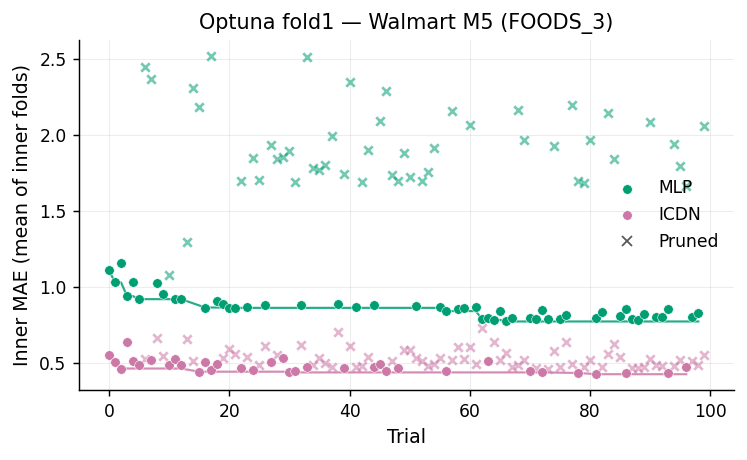

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_optuna_fold2.pdf


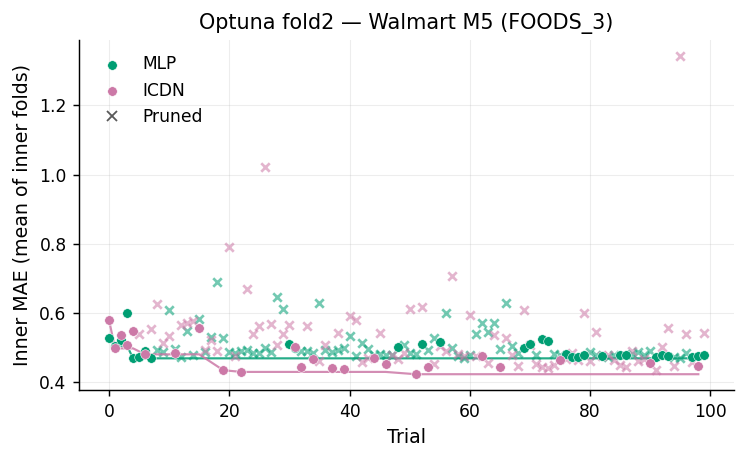

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_optuna_fold3.pdf


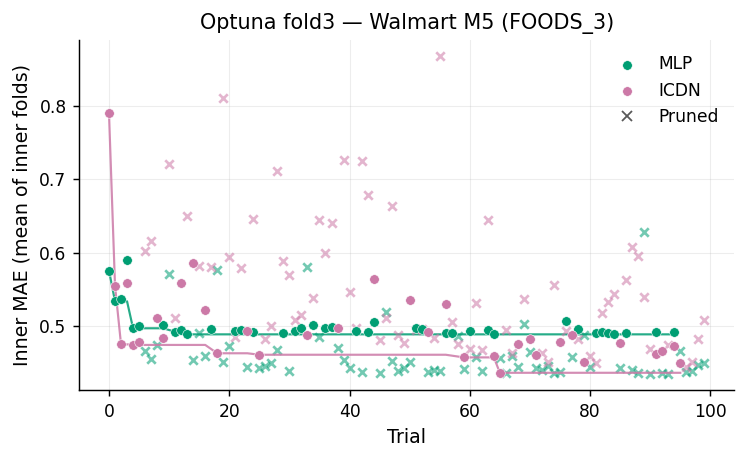

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_optuna_holdout.pdf


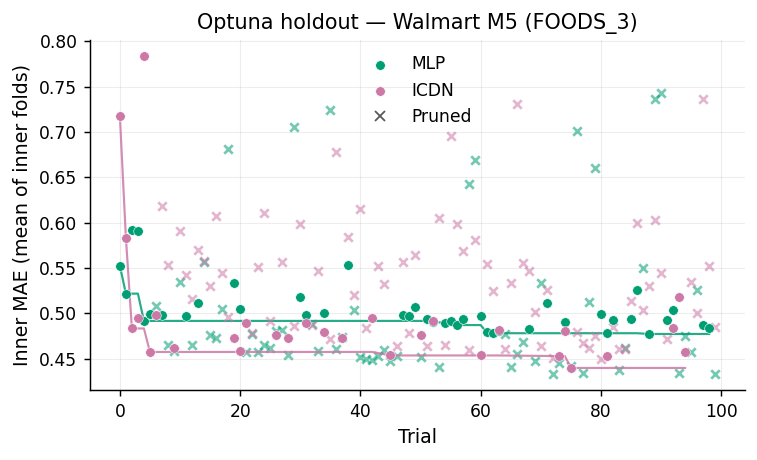

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/one_c_optuna_fold1.pdf


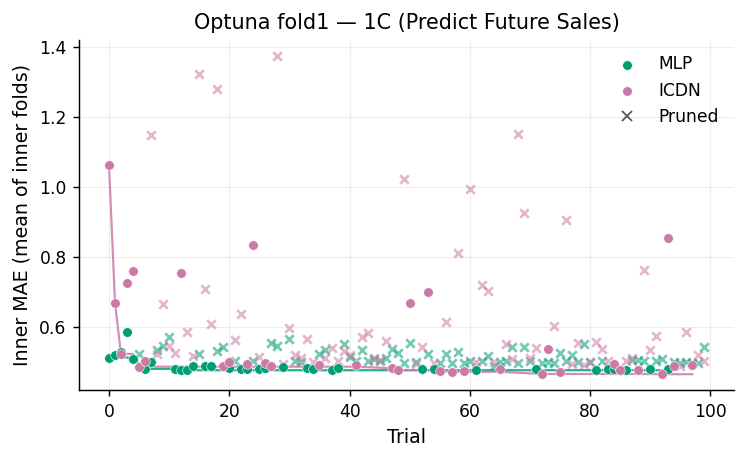

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/one_c_optuna_fold2.pdf


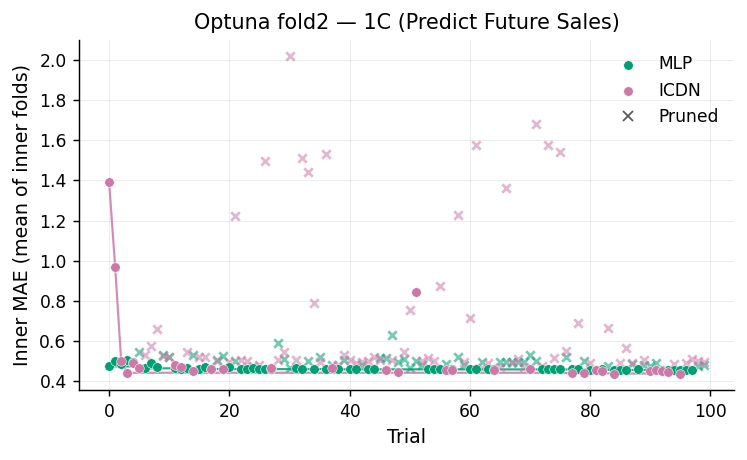

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/one_c_optuna_fold3.pdf


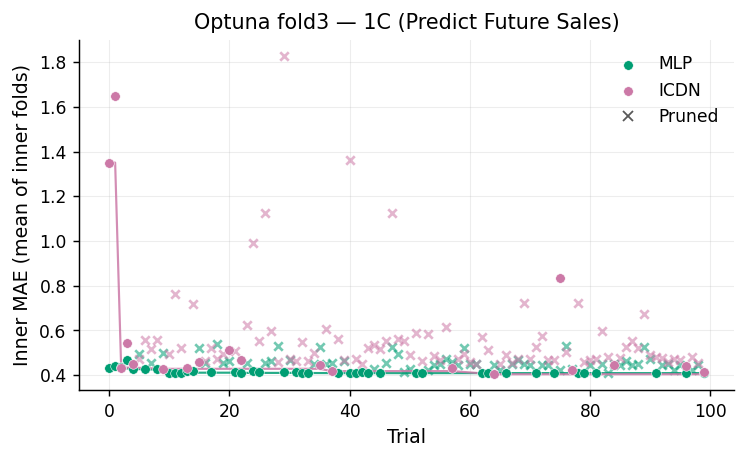

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/one_c_optuna_holdout.pdf


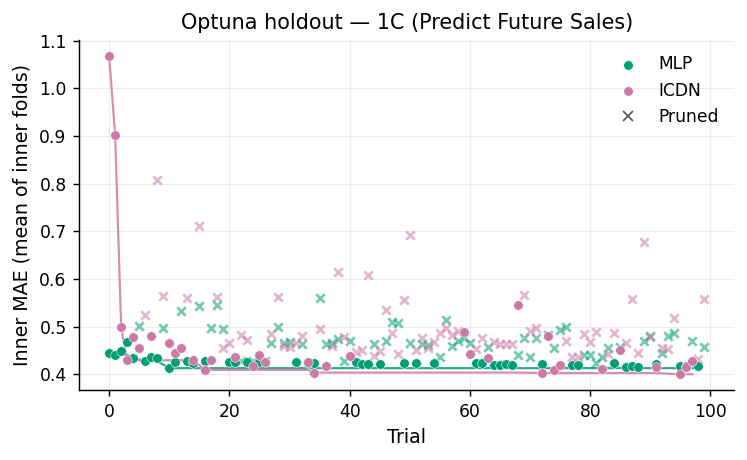

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_optuna_fold1.pdf


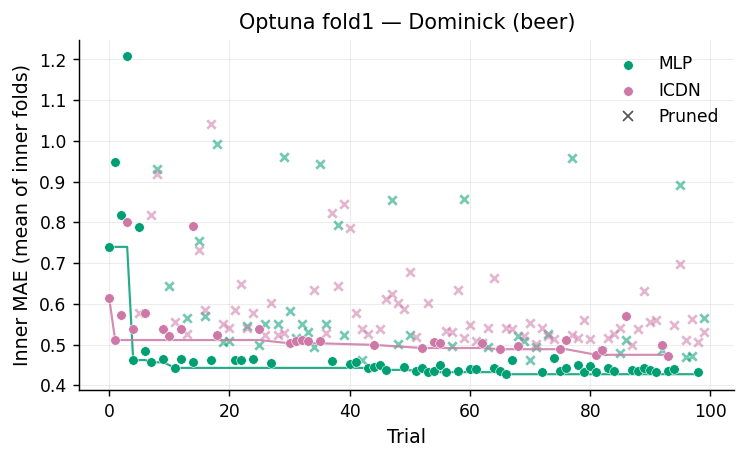

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_optuna_fold2.pdf


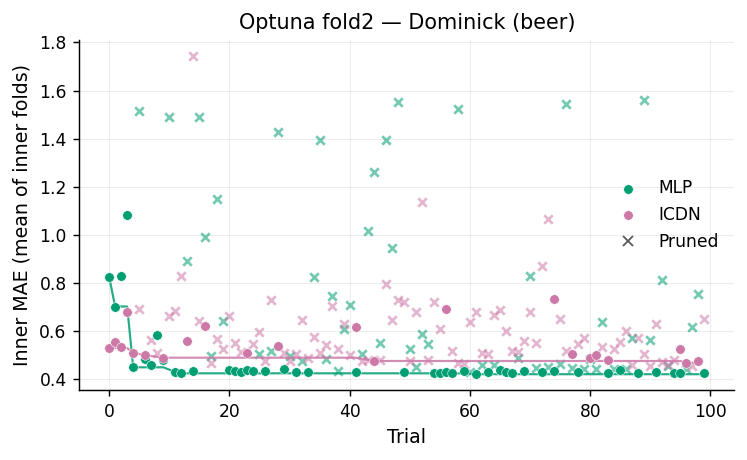

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_optuna_fold3.pdf


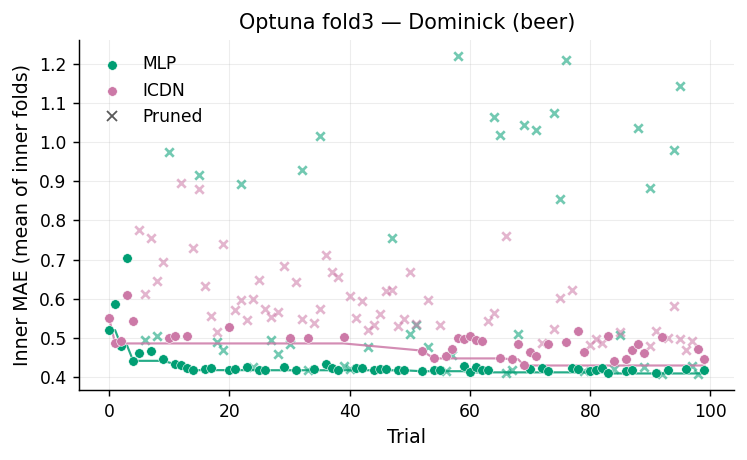

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_optuna_holdout.pdf


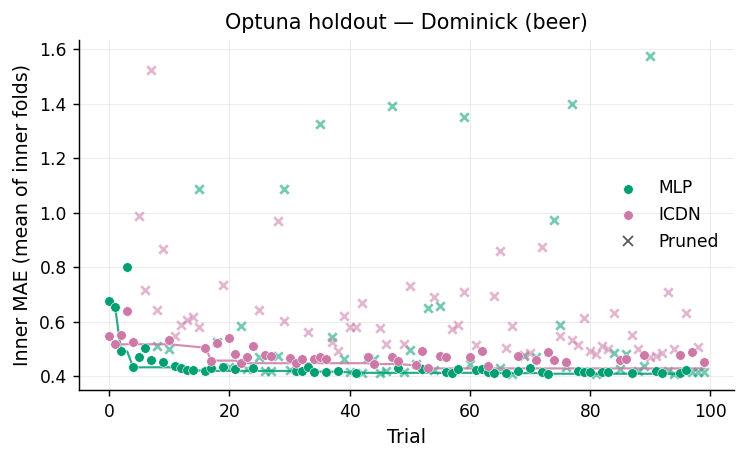

In [21]:
def load_optuna(panel: Path) -> pd.DataFrame:
    rows = []
    for model in NEURAL_MODELS:
        for path in sorted((panel / model).glob("*/optuna_trials.csv")):
            df = read_csv(path)
            if df.empty:
                continue
            df = df.copy()
            df["model"] = model
            df["stage"] = path.parent.name
            ds = load_all("kfold.csv", panel)
            df["dataset"] = ds["dataset"].iloc[0] if len(ds) else panel.parent.name
            rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


opt = pd.concat([load_optuna(p) for p in PANELS.values()], ignore_index=True)
if opt.empty:
    print("no optuna_trials.csv")
else:
    mae_cols = [c for c in opt.columns if c.startswith("user_attrs_fold") and c.endswith("_mae")]

    def trial_budget(df: pd.DataFrame) -> pd.DataFrame:
        rows = []
        for (dataset, model, stage), part in df.groupby(["dataset", "model", "stage"]):
            states = part["state"].astype(str)
            best = best_complete_trial(part)
            rec = {
                "dataset": dataset, "model": model, "stage": stage,
                "n_trials": len(part),
                "completed": int((states == "COMPLETE").sum()),
                "pruned": int((states == "PRUNED").sum()),
                "failed": int((states == "FAIL").sum()),
                "best_value": float(best["value"]) if best is not None else np.nan,
            }
            if best is not None:
                rec["best_hidden"] = best.get("params_hidden", np.nan)
                rec["best_dropout"] = best.get("params_dropout", np.nan)
                rec["best_lr"] = best.get("params_lr", np.nan)
                inner = [best[c] for c in mae_cols if c in best.index and pd.notna(best[c])]
                rec["best_inner_mae_sd"] = float(np.std(inner)) if inner else np.nan
            rows.append(rec)
        return pd.DataFrame(rows).sort_values(["dataset", "model", "stage"])

    show_table(trial_budget(opt), "Table 22. Optuna budget and winning configuration (COMPLETE trials only)")

    def plot_optuna(df: pd.DataFrame, dataset: str, stage: str, stem: str):
        part = df[(df["dataset"] == dataset) & (df["stage"] == stage)]
        if part.empty:
            return
        fig, ax = plt.subplots(figsize=(6.5, 3.5))
        for model in NEURAL_MODELS:
            m = part[part["model"] == model].sort_values("number")
            if m.empty:
                continue
            complete = m[m["state"].astype(str) == "COMPLETE"]
            pruned = m[m["state"].astype(str) == "PRUNED"]
            if len(pruned):
                ax.scatter(pruned["number"], pruned["value"], s=22, marker="x", color=COLOR[model], alpha=0.55, zorder=2)
            if len(complete):
                ax.scatter(complete["number"], complete["value"], s=28, marker="o", color=COLOR[model], label=MODEL_LABEL[model], zorder=3, edgecolors="white", linewidths=0.3)
                ax.plot(complete["number"], complete["value"].cummin(), color=COLOR[model], lw=1.2, alpha=0.85)
        ax.set_xlabel("Trial")
        ax.set_ylabel("Inner MAE (mean of inner folds)")
        ax.set_title(f"Optuna {stage} — {DATASET_LABEL[dataset]}")
        handles, labels = ax.get_legend_handles_labels()
        handles.append(Line2D([0], [0], marker="x", color="0.35", linestyle="none", label="Pruned"))
        labels.append("Pruned")
        ax.legend(handles, labels)
        savefig(fig, stem)
        plt.show()
        plt.close(fig)

    for key in PANELS:
        stages = sorted(opt.loc[opt["dataset"] == key, "stage"].unique()) if "dataset" in opt.columns else []
        for st in stages:
            plot_optuna(opt, key, st, f"{key}_optuna_{st}")


## 12. Protocol audit

`split_plan.json` / `split_plan.csv` is the shared cut: the later of the default floor, the MLP minimum, and the ICDN minimum. OLS, Ridge, MLP, and ICDN read that manifest; they do not choose their own outer fold.

`bootstrap_plan.json` is the shared draw: each replica stores source blocks, `bootstrap_order`, validation weeks, and the frozen calendar of the original holdout train. All four models read that plan.

`run_manifest.csv` records train / early-stop / validation clocks, the frozen-universe hash, and the seed. The four models must share `frozen_products_hash` and the same validation window in a given fold.

`bootstrap_manifest.csv` flattens block JSON. `period_overlap_flag` is true if the same `source_week` enters two blocks of a replica (sampling with replacement of the partition). Validation is never resampled.

`run_failures.csv` lists omitted folds/replicas. `spline_support_diagnostics.csv` counts observed log-prices outside ICDN spline knots (cubic extrapolation).


In [22]:
man_parts, fail_parts, spl_parts, bman_parts, plan_parts = [], [], [], [], []
for p in PANELS.values():
    man_parts.append(read_csv(p / "run_manifest.csv"))
    fail_parts.append(read_csv(p / "run_failures.csv"))
    spl_parts.append(read_csv(p / "spline_support_diagnostics.csv"))
    bman_parts.append(read_csv(p / "bootstrap_manifest.csv"))
    plan_parts.append(read_csv(p / "split_plan.csv"))
manifest = pd.concat([x for x in man_parts if len(x)], ignore_index=True) if any(len(x) for x in man_parts) else pd.DataFrame()
failures = pd.concat([x for x in fail_parts if len(x)], ignore_index=True) if any(len(x) for x in fail_parts) else pd.DataFrame()
spline = pd.concat([x for x in spl_parts if len(x)], ignore_index=True) if any(len(x) for x in spl_parts) else pd.DataFrame()
bman = pd.concat([x for x in bman_parts if len(x)], ignore_index=True) if any(len(x) for x in bman_parts) else pd.DataFrame()
plans = pd.concat([x for x in plan_parts if len(x)], ignore_index=True) if any(len(x) for x in plan_parts) else pd.DataFrame()

if plans.empty:
    print("split_plan.csv missing.")
else:
    show_table(plans.sort_values(["dataset", "fold"]), "Shared split plan (one manifest per dataset)")

boot_plan_rows = []
for key, p in PANELS.items():
    path = p / "bootstrap_plan.json"
    if not path.exists():
        continue
    payload = json.loads(path.read_text())
    cal = payload.get("calendar") or {}
    boot_plan_rows.append({
        "dataset": payload.get("dataset", key),
        "n_boot": payload.get("n_boot"),
        "n_train_periods": payload.get("n_train_periods"),
        "block_size": payload.get("block_size"),
        "seed": payload.get("seed"),
        "calendar_origin": cal.get("origin"),
        "max_train_rank": cal.get("max_train_rank"),
        "n_val_weeks": len(payload.get("val_weeks") or []),
        "n_replicates": len(payload.get("replicates") or []),
    })
if boot_plan_rows:
    show_table(pd.DataFrame(boot_plan_rows), "Shared bootstrap plan (one draw per dataset)")
else:
    print("bootstrap_plan.json missing.")

if len(manifest):
    show_table(manifest.sort_values(["dataset", "outer_fold", "model"]), "Table 23. Split manifest")
    hash_ok = (
        manifest.groupby(["dataset", "stage", "outer_fold"])["frozen_products_hash"]
        .nunique()
        .rename("n_distinct_universe_hashes")
        .reset_index()
    )
    show_table(hash_ok, "One frozen universe per split (must be 1)")
    val_ok = (
        manifest.groupby(["dataset", "stage", "outer_fold"])
        .agg(n_val_min=("validation_week_min", "nunique"), n_val_max=("validation_week_max", "nunique"))
        .reset_index()
    )
    show_table(val_ok, "Same validation window per split (nunique must be 1)")

if bman.empty:
    print("bootstrap_manifest.csv has no rows.")
else:
    show_table(bman.head(20), "Table 24. First bootstrap blocks (sample)")
    same = (
        bman.groupby(["dataset", "bootstrap_id", "source_block_id"])
        .agg(
            n_models=("model", "nunique"),
            n_source_start=("source_week_start", "nunique"),
            n_boot_start=("bootstrap_week_start", "nunique"),
            any_overlap=("period_overlap_flag", "max"),
        )
        .reset_index()
    )
    show_table(same, "Blocks aligned across models (n_source_start = 1 and n_boot_start = 1)")

if failures.empty:
    print("run_failures.csv empty: no recorded skips.")
else:
    show_table(failures, "Table 25. Omitted folds / trials / replicates")

if spline.empty or spline.dropna(how="all").empty:
    print("spline_support_diagnostics.csv empty until the next ICDN fit.")
else:
    show_table(spline, "Table 26. ICDN spline-support extrapolation")


**Shared split plan (one manifest per dataset)**

,dataset,fold,train_week_min,train_week_max,val_week_min,val_week_max,n_train_periods,n_val_periods,min_train,n_holdout_train
8,dominick,1,1,110,111,146,110,36,110,176
9,dominick,2,1,146,147,182,146,36,110,176
10,dominick,3,1,182,183,220,182,38,110,176
11,dominick,holdout,1,176,177,220,176,44,110,176
4,one_c,1,5,75,76,98,71,23,71,113
5,one_c,2,5,98,99,121,94,23,71,113
6,one_c,3,5,121,122,146,117,25,71,113
7,one_c,holdout,5,117,118,146,113,29,71,113
0,walmart,1,1,138,139,184,138,46,138,221
1,walmart,2,1,184,185,230,184,46,138,221


**Shared bootstrap plan (one draw per dataset)**

,dataset,n_boot,n_train_periods,block_size,seed,calendar_origin,max_train_rank,n_val_weeks,n_replicates
0,walmart,100,221,20,42,1,221,56,100
1,one_c,100,113,20,42,5,113,29,100
2,dominick,100,176,20,42,1,176,44,100


**Table 23. Split manifest**

...

**Blocks aligned across models (n_source_start = 1 and n_boot_start = 1)**

,dataset,bootstrap_id,source_block_id,n_models,n_source_start,n_boot_start,any_overlap
0,dominick,0,0,4,1,1,True
1,dominick,0,1,4,1,1,True
2,dominick,0,2,4,1,1,True
3,dominick,0,3,4,1,1,True
4,dominick,0,4,4,1,1,True
...,...,...,...,...,...,...,...
2795,walmart,99,8,4,1,1,True
2796,walmart,99,9,4,1,1,True
2797,walmart,99,10,4,1,1,True
2798,walmart,99,11,4,1,1,True


run_failures.csv empty: no recorded skips.


**Table 26. ICDN spline-support extrapolation**

,dataset,model,fold_or_boot_id,n_observed_cells,n_below_support,n_above_support,share_outside_support
0,walmart,icdn,1,8217,994,663,0.2017
1,walmart,icdn,2,7268,638,1654,0.3154
2,walmart,icdn,3,7297,240,2635,0.3940
3,walmart,icdn,holdout,8453,632,2923,0.4206
4,walmart,icdn,boot0,8453,657,680,0.1582
...,...,...,...,...,...,...,...
307,dominick,icdn,boot95,17215,36,6593,0.3851
308,dominick,icdn,boot96,17215,2,3891,0.2261
309,dominick,icdn,boot97,17215,40,4378,0.2566
310,dominick,icdn,boot98,17215,40,3891,0.2283


## Notes for the paper

1. Always report **native** and **matched**. OLS MAE on fewer cells is not comparable with MLP MAE at full coverage.
2. Native `cross_mean` is not an ICDN–MLP contrast. Use the edge intersection.
3. Linear own-price is \(\mathrm{mean}_{j\in J_i}\widehat\beta_{ij}^{\mathrm{own}}\). Without a stable `n_partners`, `fold_sd` mixes a change in \(J_i\) with a change in \(\beta\).
4. The percentile bootstrap is per series. `bootstrap_matched_global` is not a CI for mean market elasticity.
5. With \(B=2\), the 2.5/97.5 percentile is degenerate: a code diagnostic, not a sampling interval. Paired SD comparisons on two common IDs are likewise a pipeline check.
6. Predictive \(\Delta\mathrm{MAE}\) uses a week-block bootstrap of **already fitted** outer predictions. It is not a bootstrap of the training experiment.
7. ICDN cross-price uncertainty has two parts: variation of the elasticity when the edge is selected, and variation in whether the edge is selected. `edge_selection_frequency` is the second; do not read it as an elasticity SD.
8. The non-inferiority margin \(\delta\) was fixed in `PRED_NI_MARGIN` before inspecting the paired CI.
